In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Using raw string to avoid issues with backslashes
df = pd.read_csv("data/raw/raw_final.csv", index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30065 entries, 0 to 30064
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      30065 non-null  float64
 1   Gender                    30065 non-null  float64
 2   Age                       30065 non-null  float64
 3   Race                      30065 non-null  float64
 4   PIR                       27524 non-null  float64
 5   Weight                    29603 non-null  float64
 6   Height                    29635 non-null  float64
 7   BMI                       29511 non-null  float64
 8   WaistCircumference        28600 non-null  float64
 9   Hba1c                     28397 non-null  float64
 10  FastingGlucose            28302 non-null  float64
 11  Albumin                   27953 non-null  float64
 12  ALT                       27923 non-null  float64
 13  AST                       27912 non-null  float64
 14  Alkali

In [3]:
# Remove columns not needed to measure data quality
remove_columns = ['SEQN', 'YearID']

df_dq = df.drop(columns=remove_columns)

In [4]:
# Describe data
df_dq.describe()

,Gender,Age,Race,PIR,Weight,Height,BMI,WaistCircumference,Hba1c,FastingGlucose,...,LDLCholesterol,Hemoglobin,Hematocrit,MeanCellVolumn,MeanCellHemoglobin,RedCellDistributionWidth,PlateletCount,MeanPlateletVolume,milk_consumption,VitaminD
count,30065.000000,30065.000000,30065.000000,2.752400e+04,29603.000000,29635.000000,29511.000000,28600.000000,28397.000000,28302.000000,...,27040.000000,28430.000000,28430.000000,28430.000000,28437.000000,28430.000000,28429.000000,28429.000000,3.006400e+04,27722.000000
mean,1.509795,42.055247,2.964776,2.409231e+00,77.759839,166.845144,27.808903,94.892441,5.624640,105.512805,...,2.818153,14.144442,41.847925,88.790823,33.782270,13.147531,252.426392,8.216663,2.001264e+00,61.177916
std,0.499912,21.568578,1.202015,1.611717e+00,21.924181,10.184582,7.018505,17.433479,1.007977,33.886849,...,0.921701,1.538921,4.351836,5.906244,1.007795,1.332284,67.487238,0.916113,1.093262e+00,25.797952
min,1.000000,12.000000,1.000000,5.397605e-79,25.100000,123.100000,12.610000,52.000000,3.300000,21.000000,...,0.233000,5.900000,16.300000,50.800000,25.100000,9.700000,4.000000,4.700000,5.397605e-79,5.490000
25%,1.000000,21.000000,2.000000,1.040000e+00,62.400000,159.400000,22.800000,81.700000,5.100000,91.000000,...,2.170000,13.100000,38.900000,85.800000,33.200000,12.300000,207.000000,7.600000,1.000000e+00,43.200000
50%,2.000000,40.000000,3.000000,1.980000e+00,74.800000,166.400000,26.800000,94.000000,5.400000,98.000000,...,2.720000,14.100000,41.900000,89.300000,33.800000,12.900000,245.000000,8.100000,2.000000e+00,58.700000
75%,2.000000,60.000000,4.000000,3.820000e+00,89.700000,174.200000,31.400000,105.900000,5.700000,107.000000,...,3.362000,15.200000,44.900000,92.400000,34.400000,13.600000,290.000000,8.800000,3.000000e+00,75.300000
max,2.000000,85.000000,5.000000,5.000000e+00,371.000000,204.100000,130.210000,176.000000,18.000000,686.200000,...,16.266000,19.700000,59.000000,121.900000,69.600000,37.800000,1000.000000,13.600000,9.000000e+00,375.000000


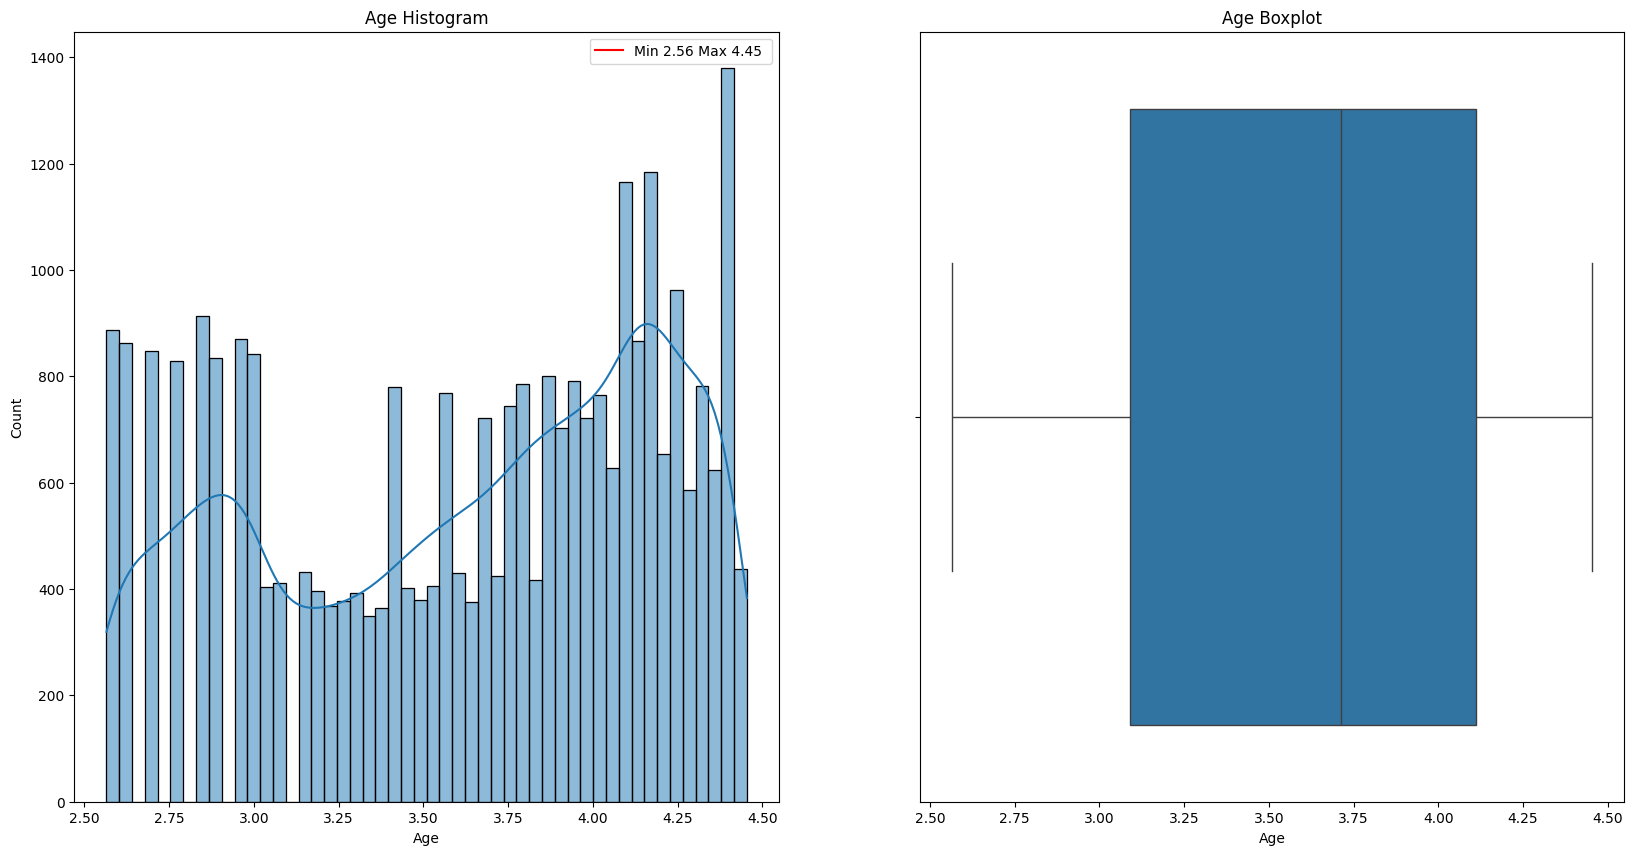

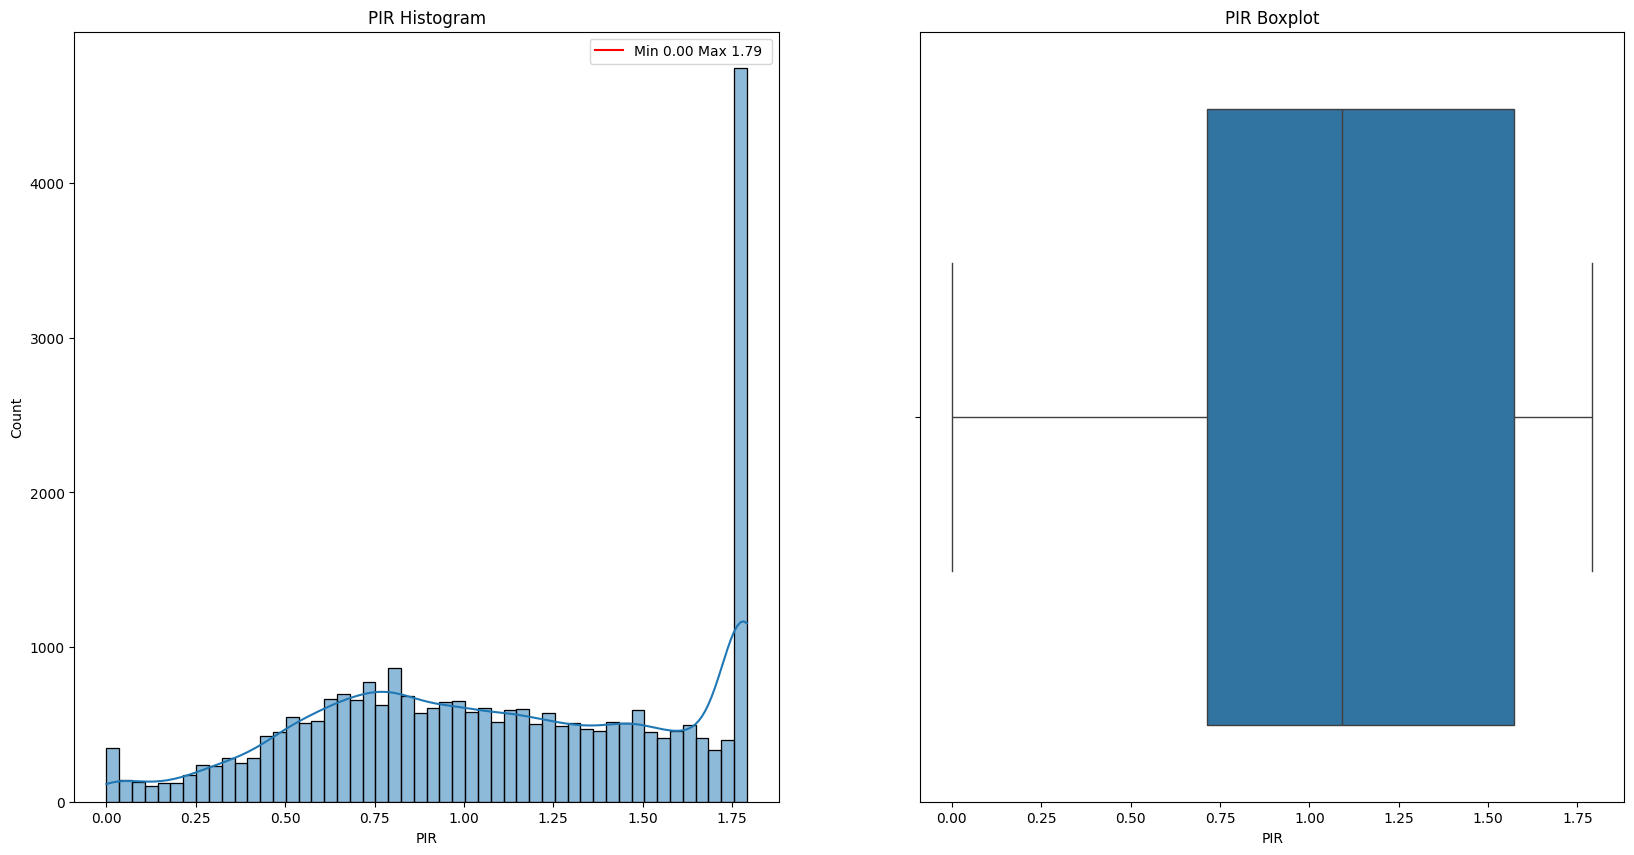

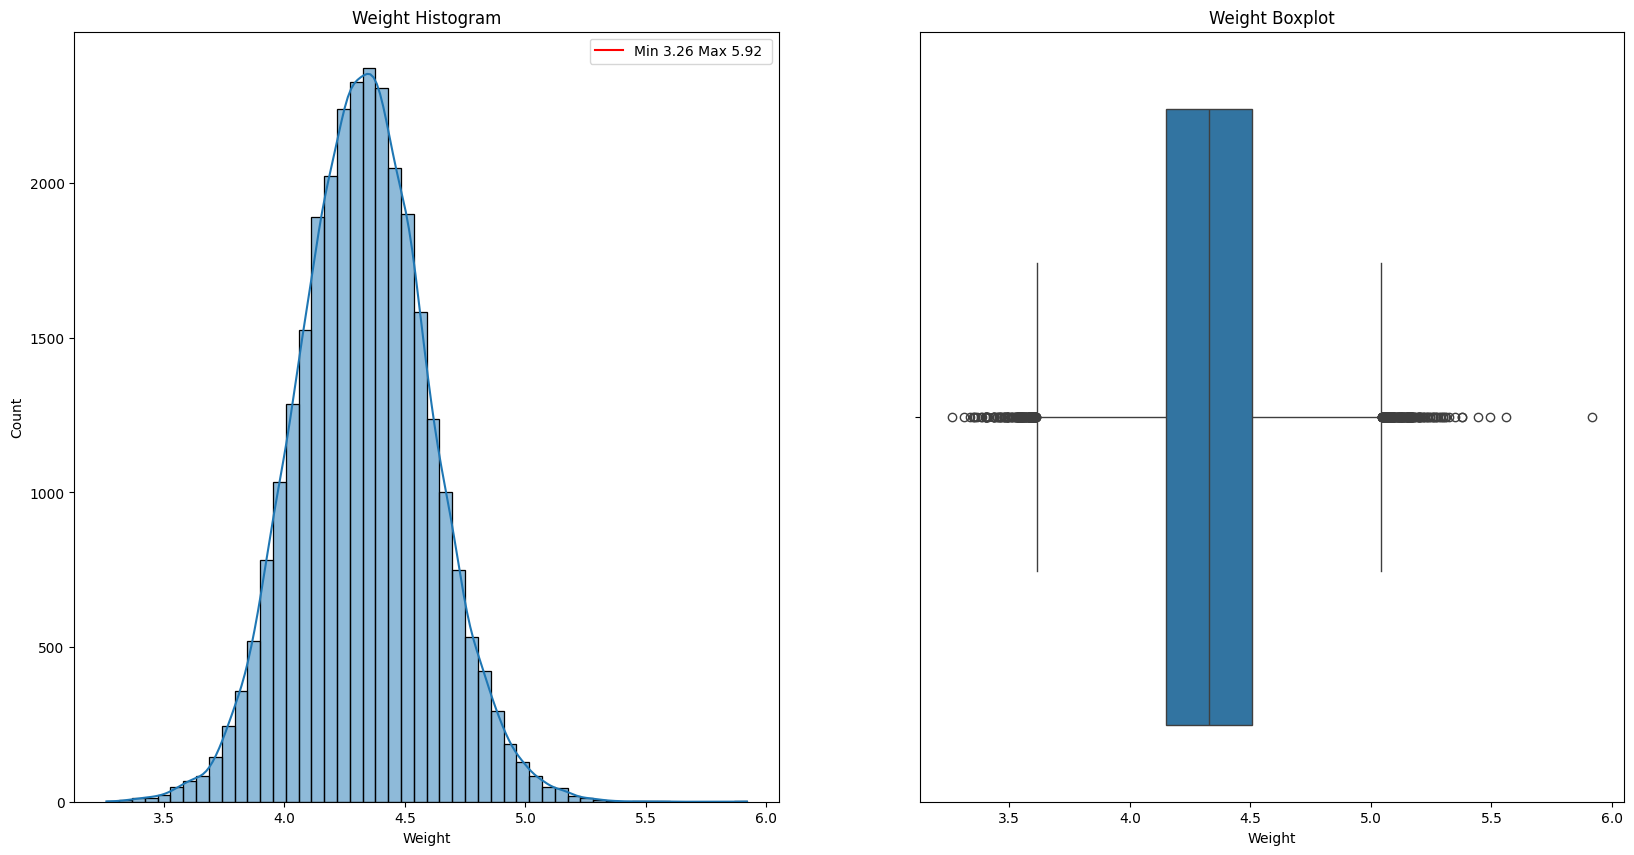

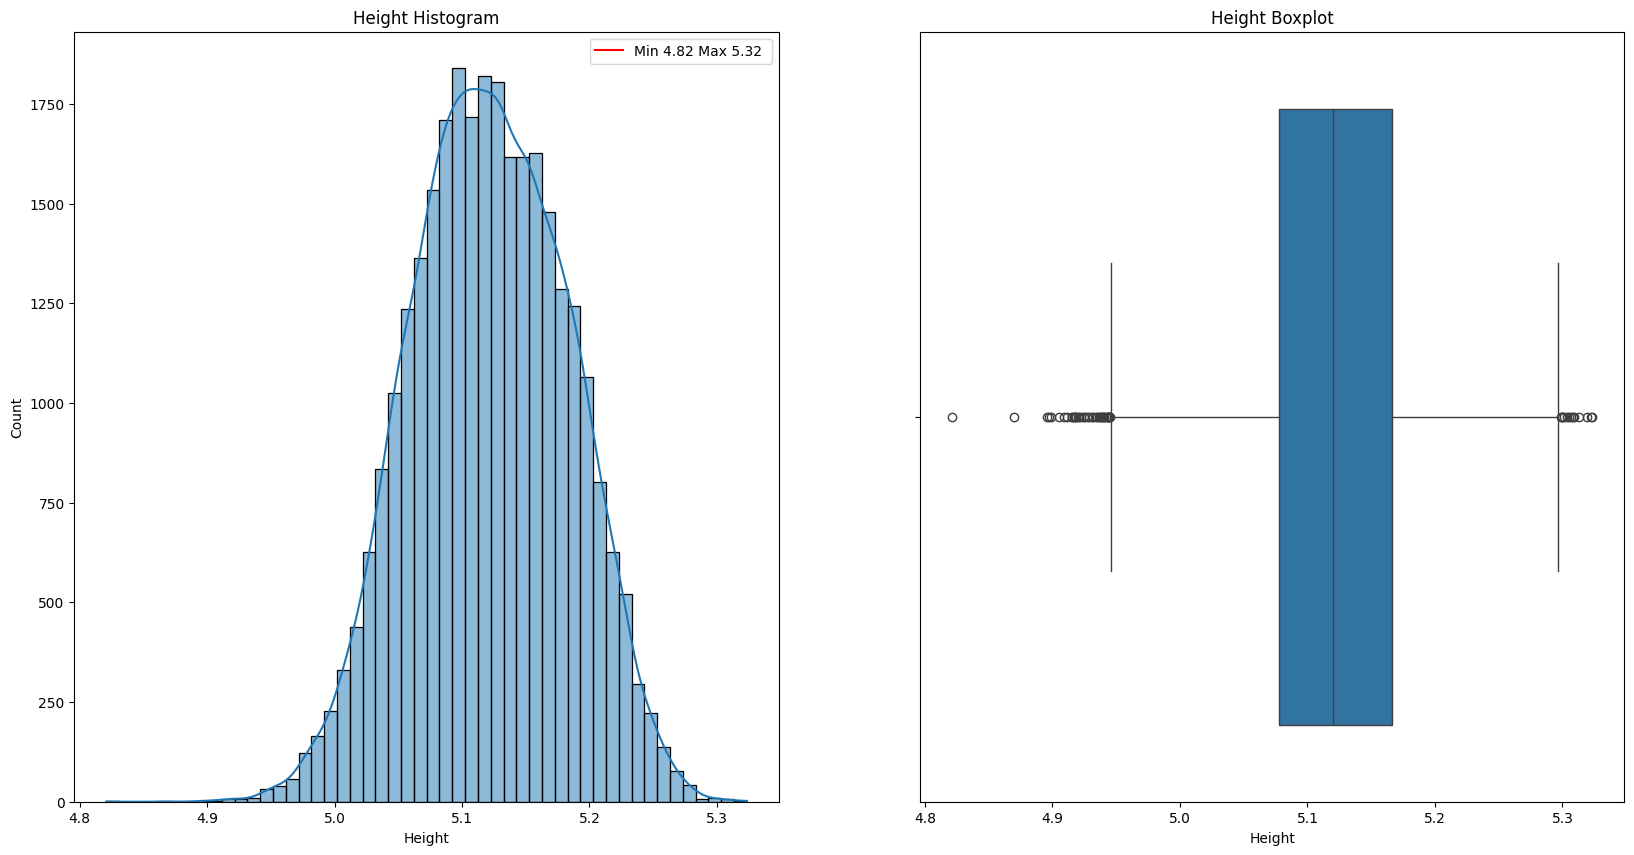

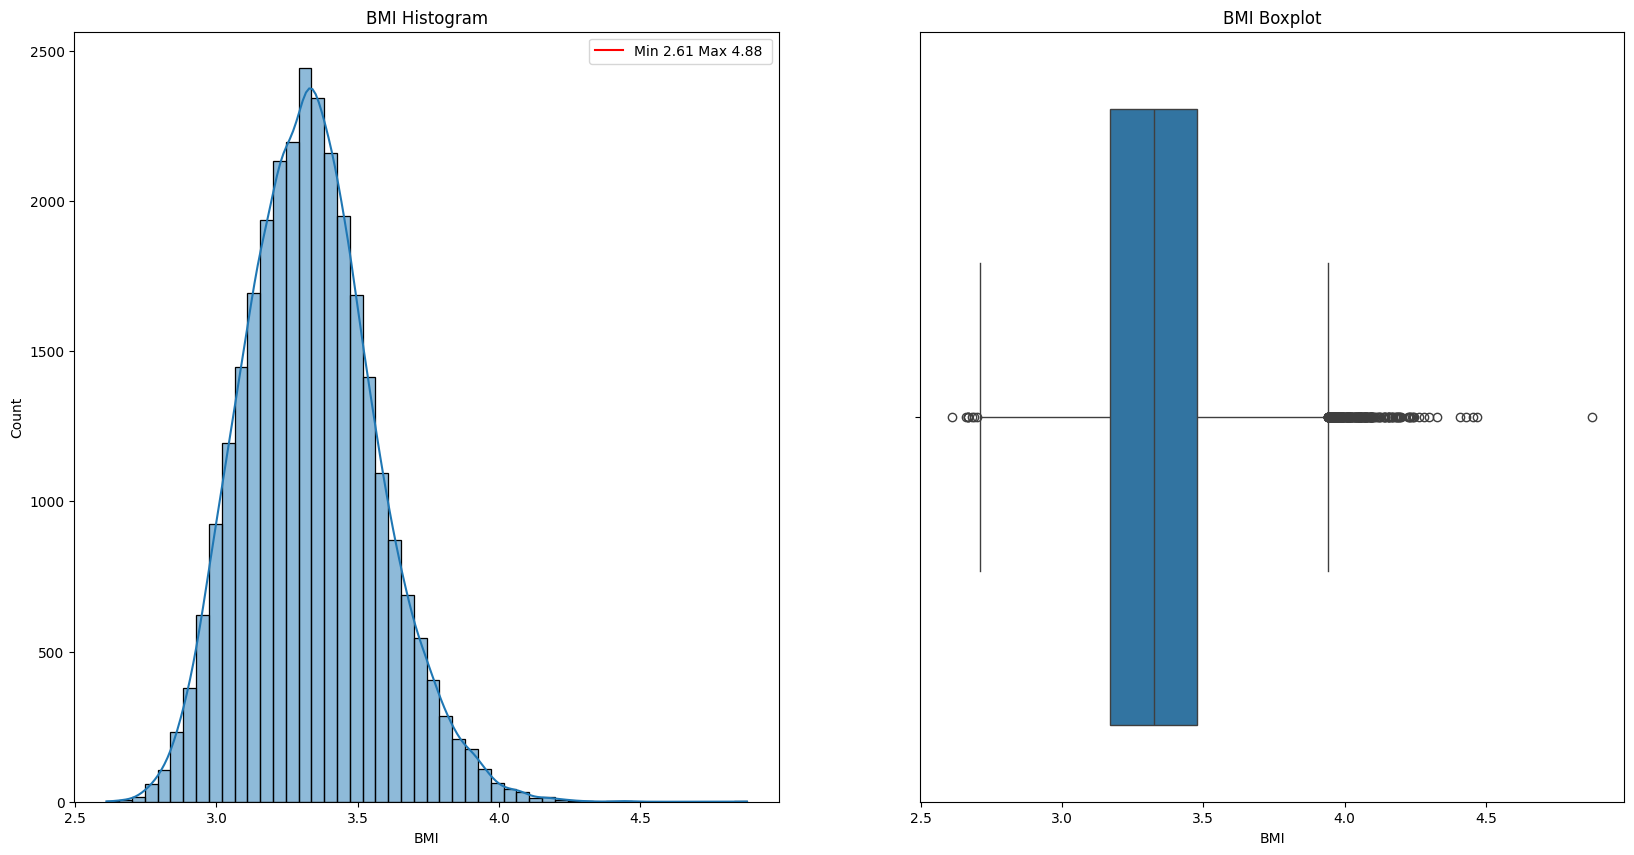

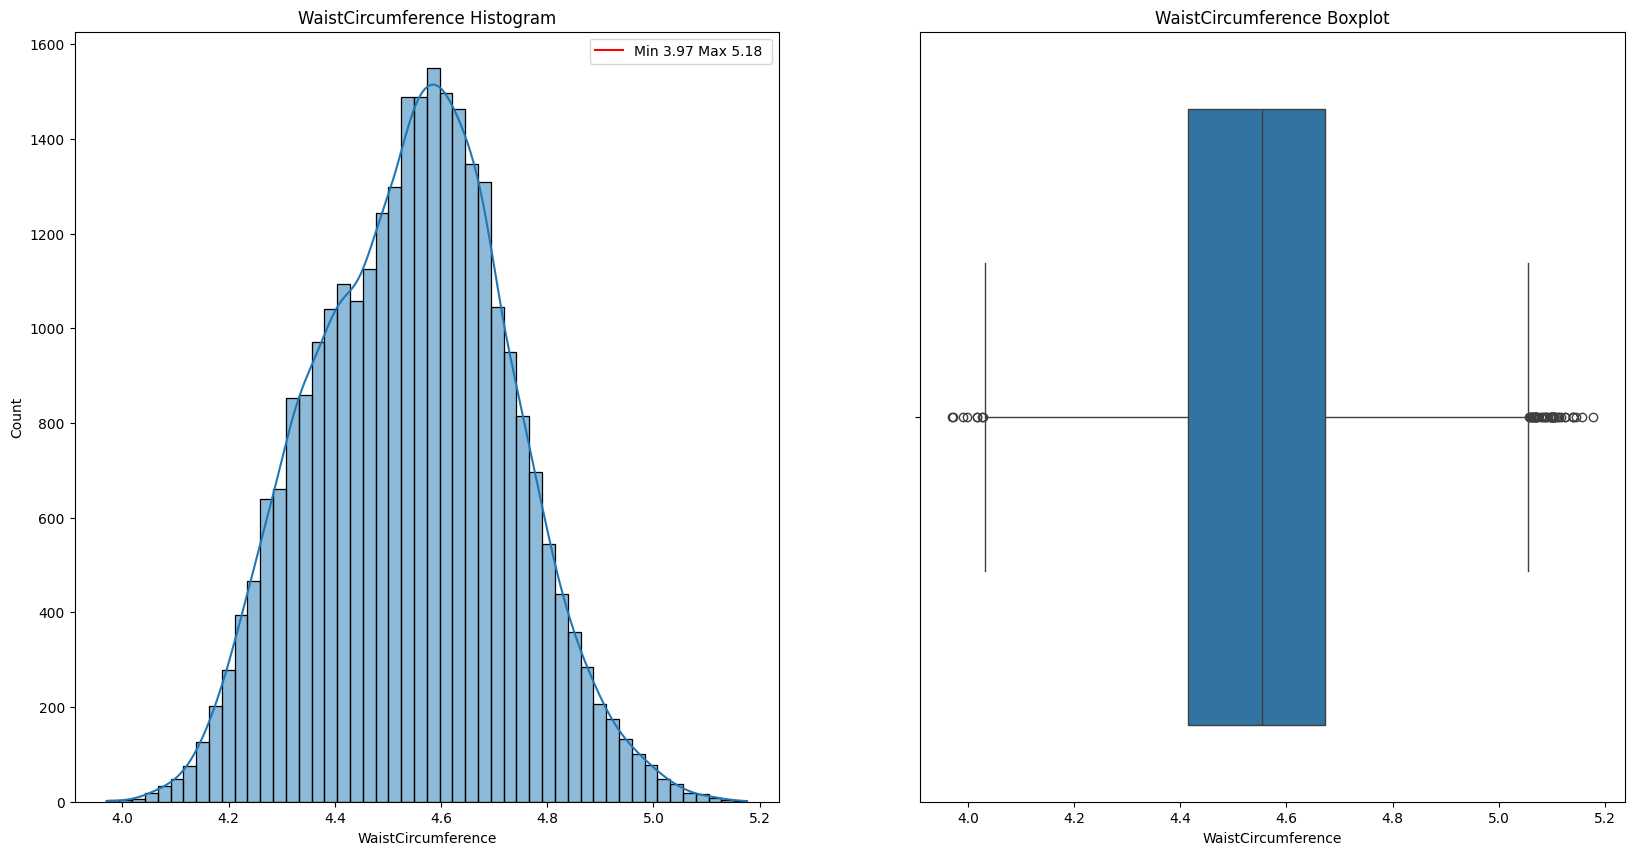

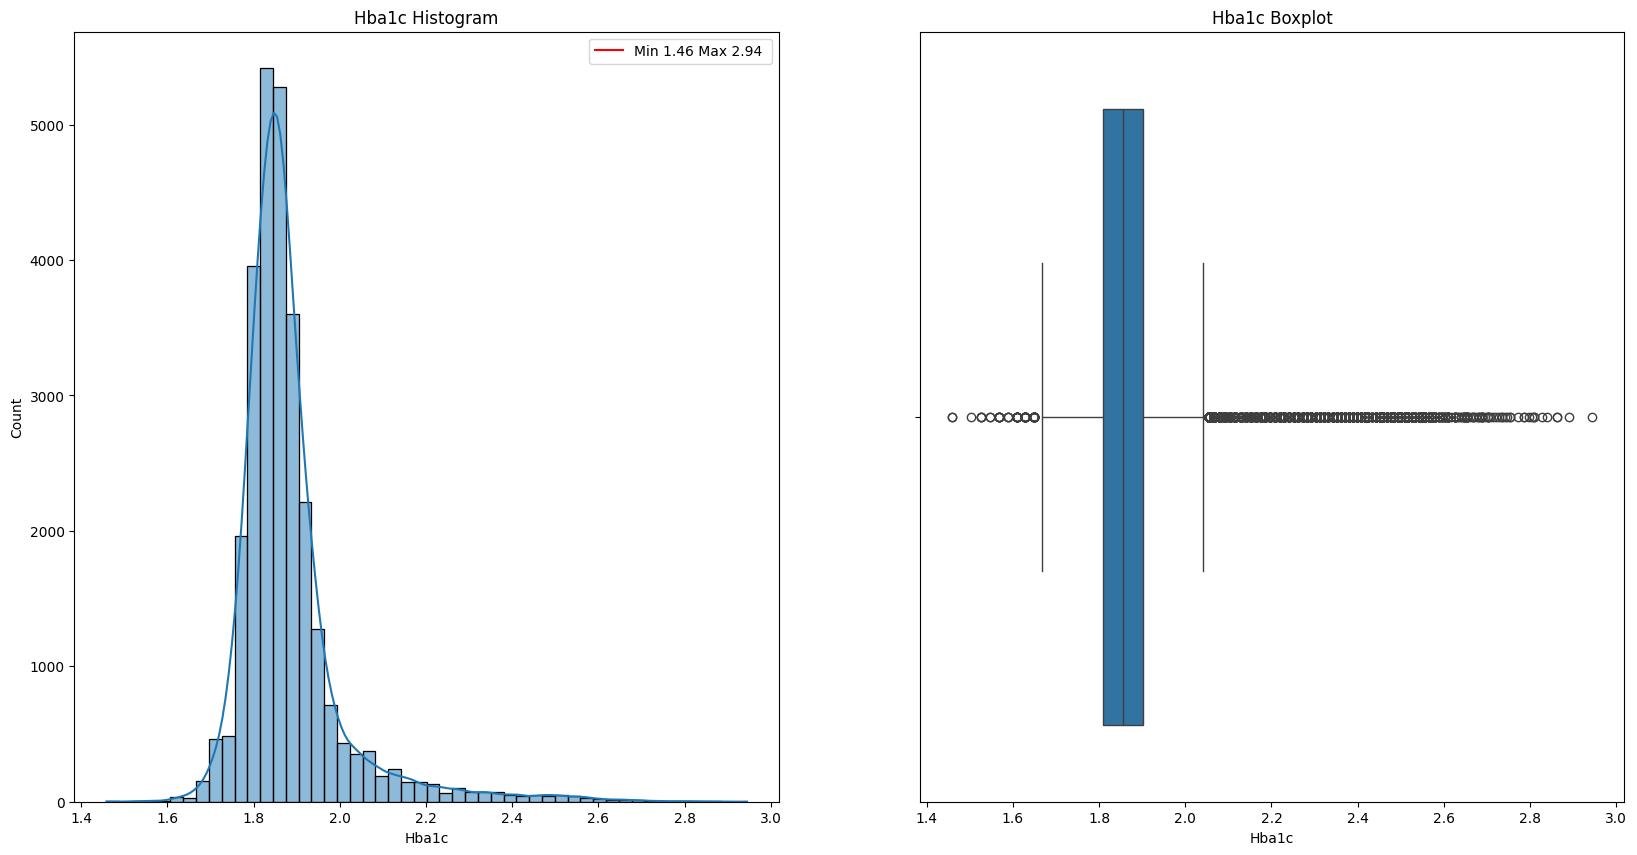

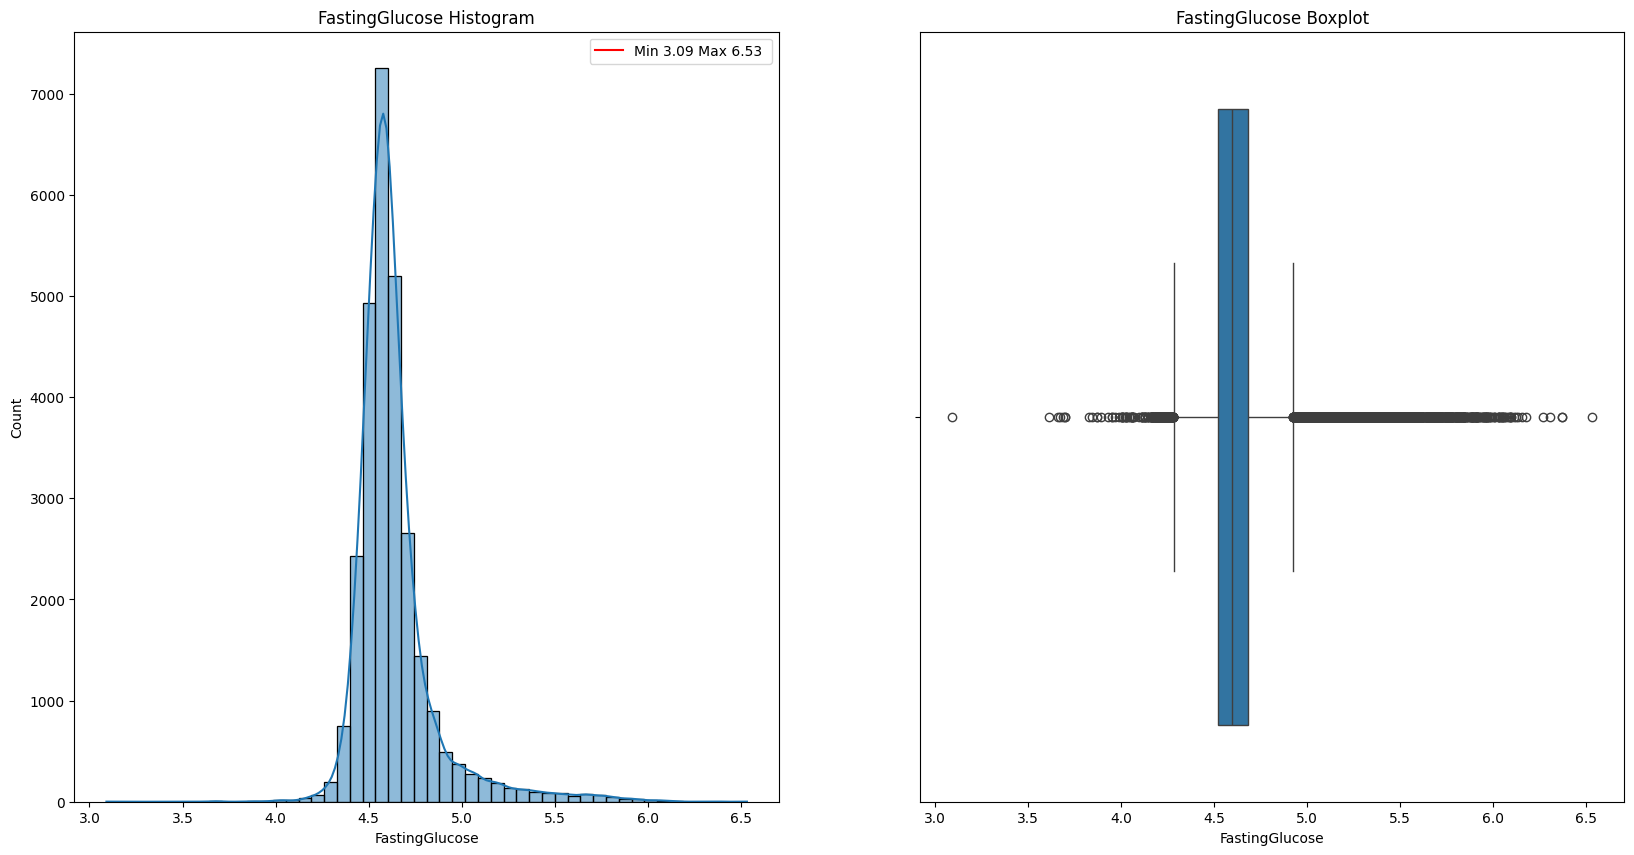

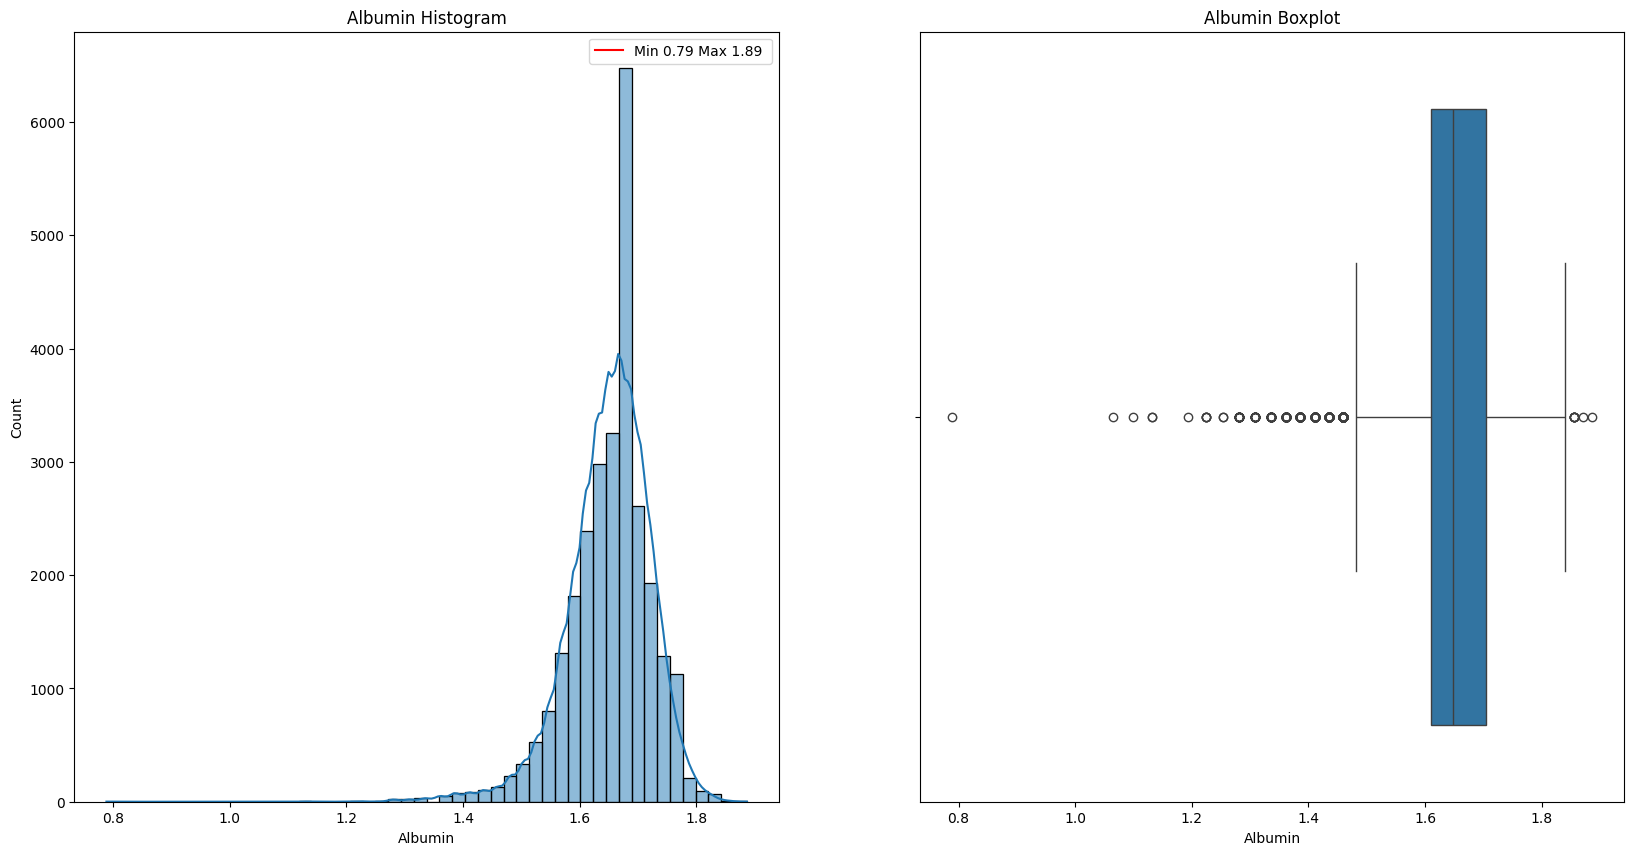

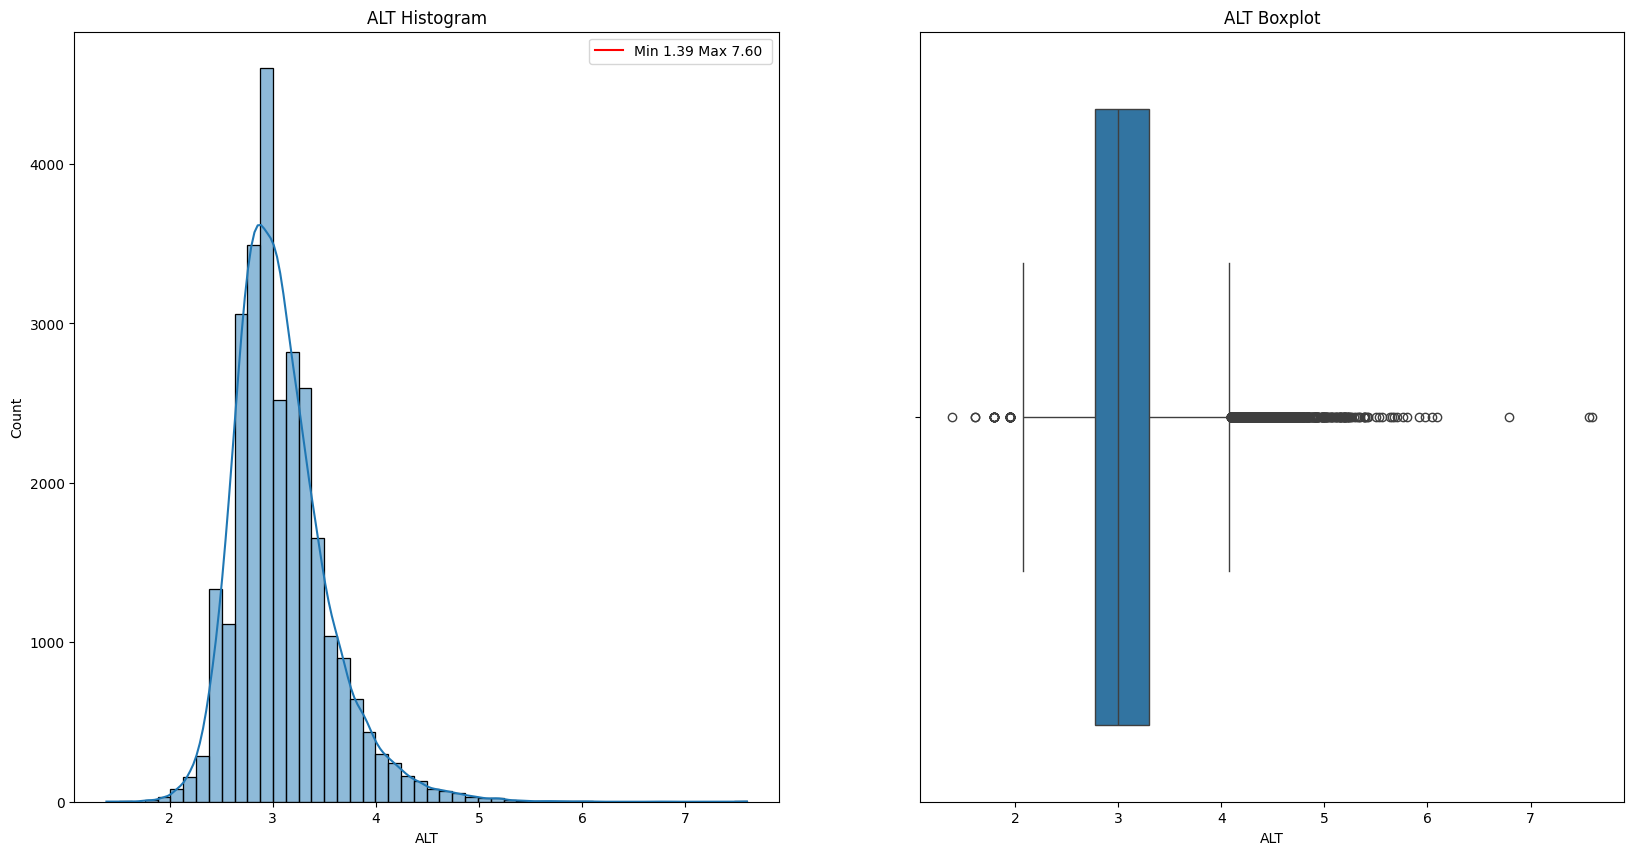

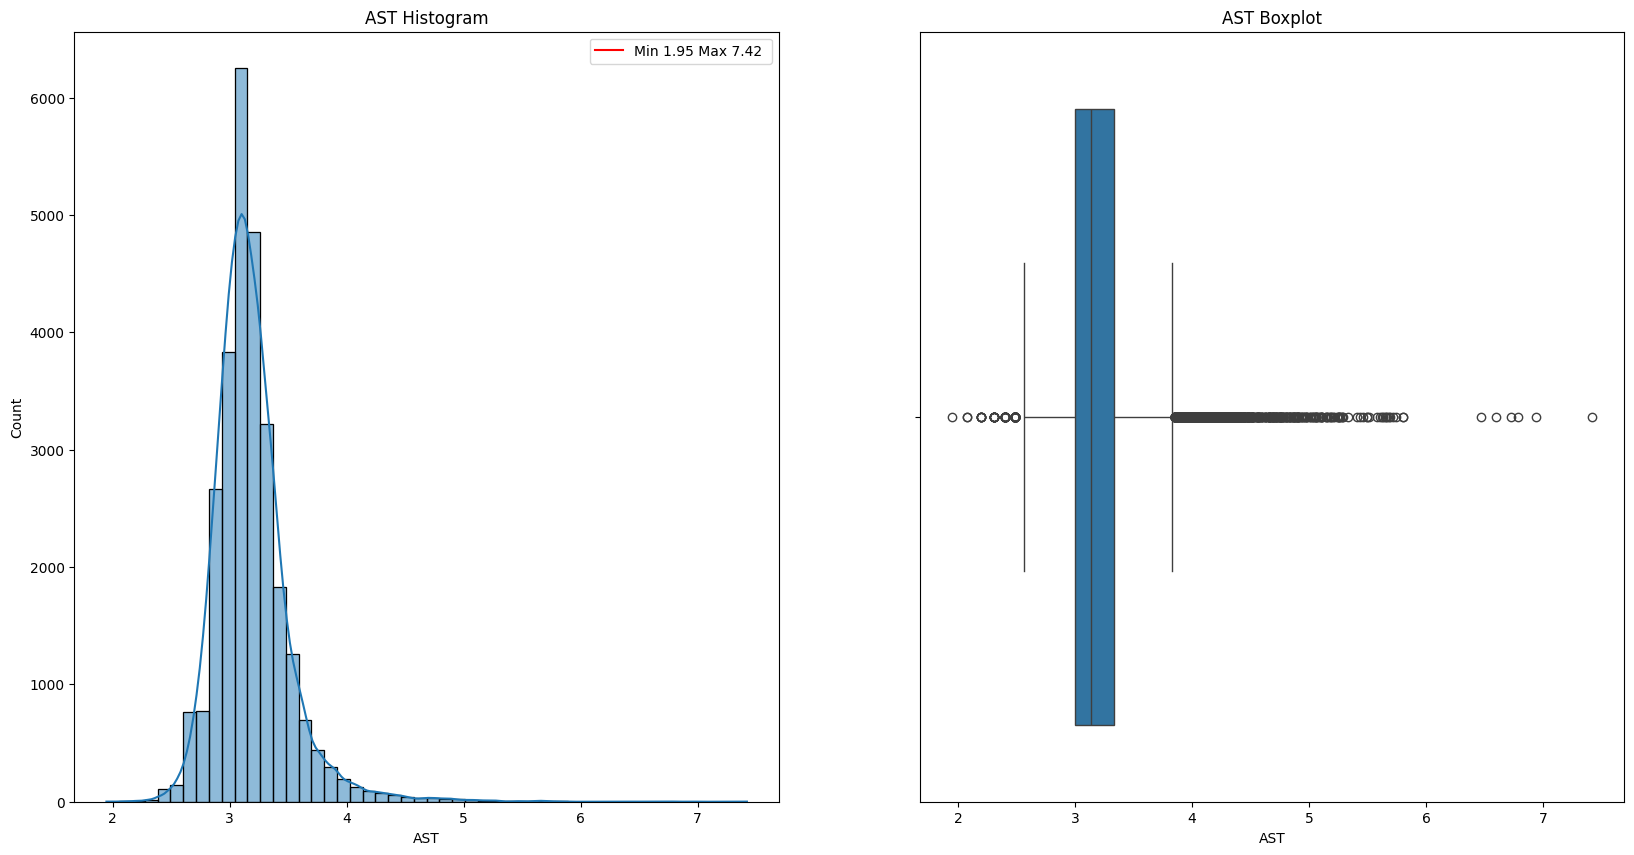

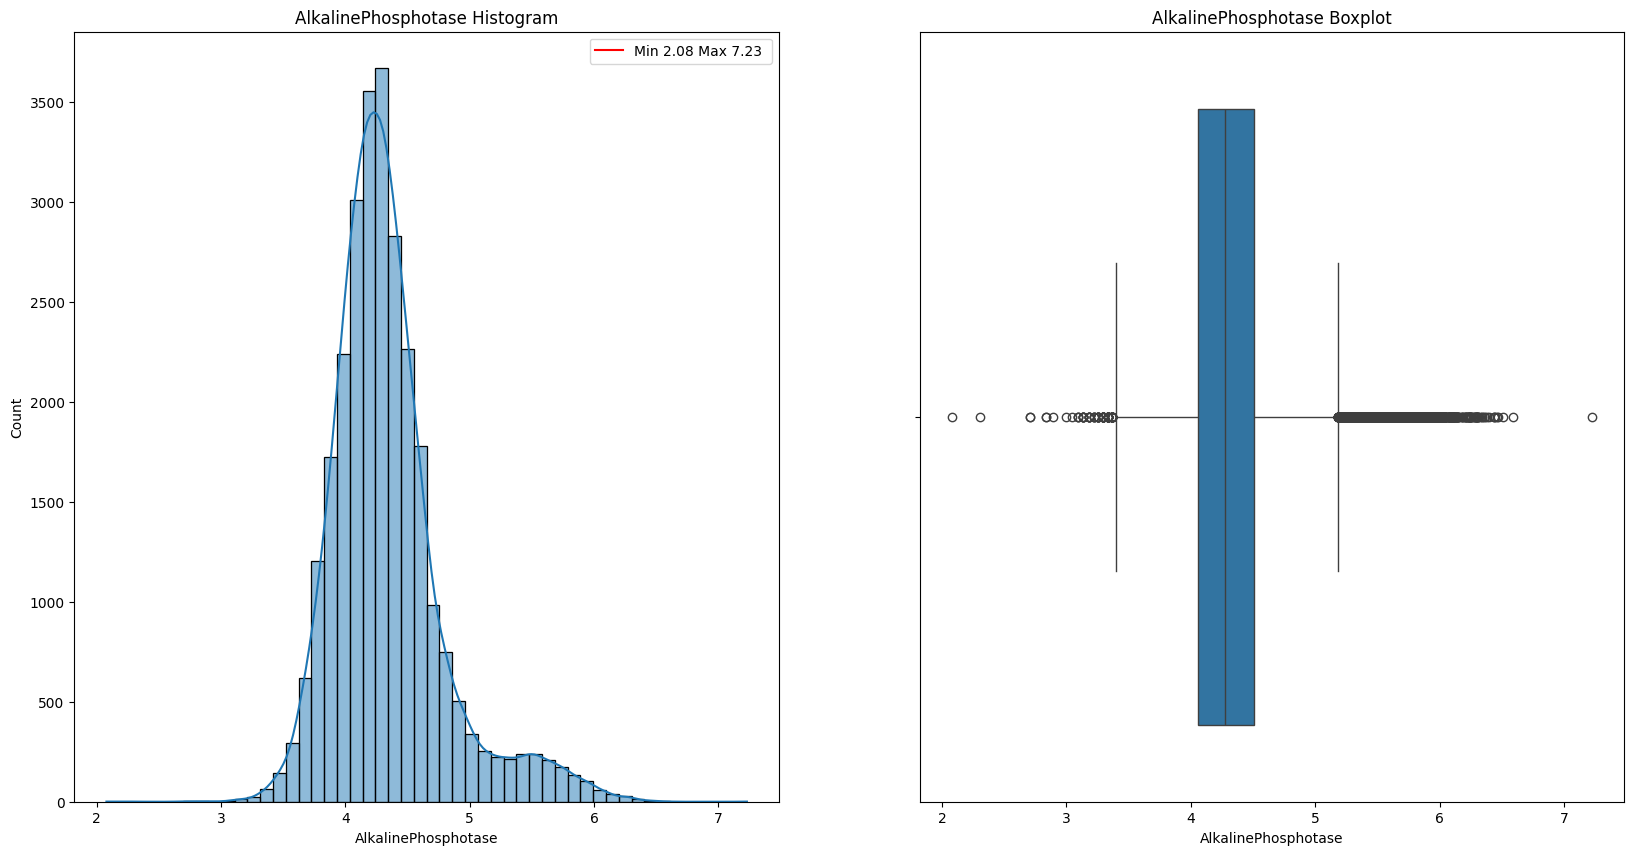

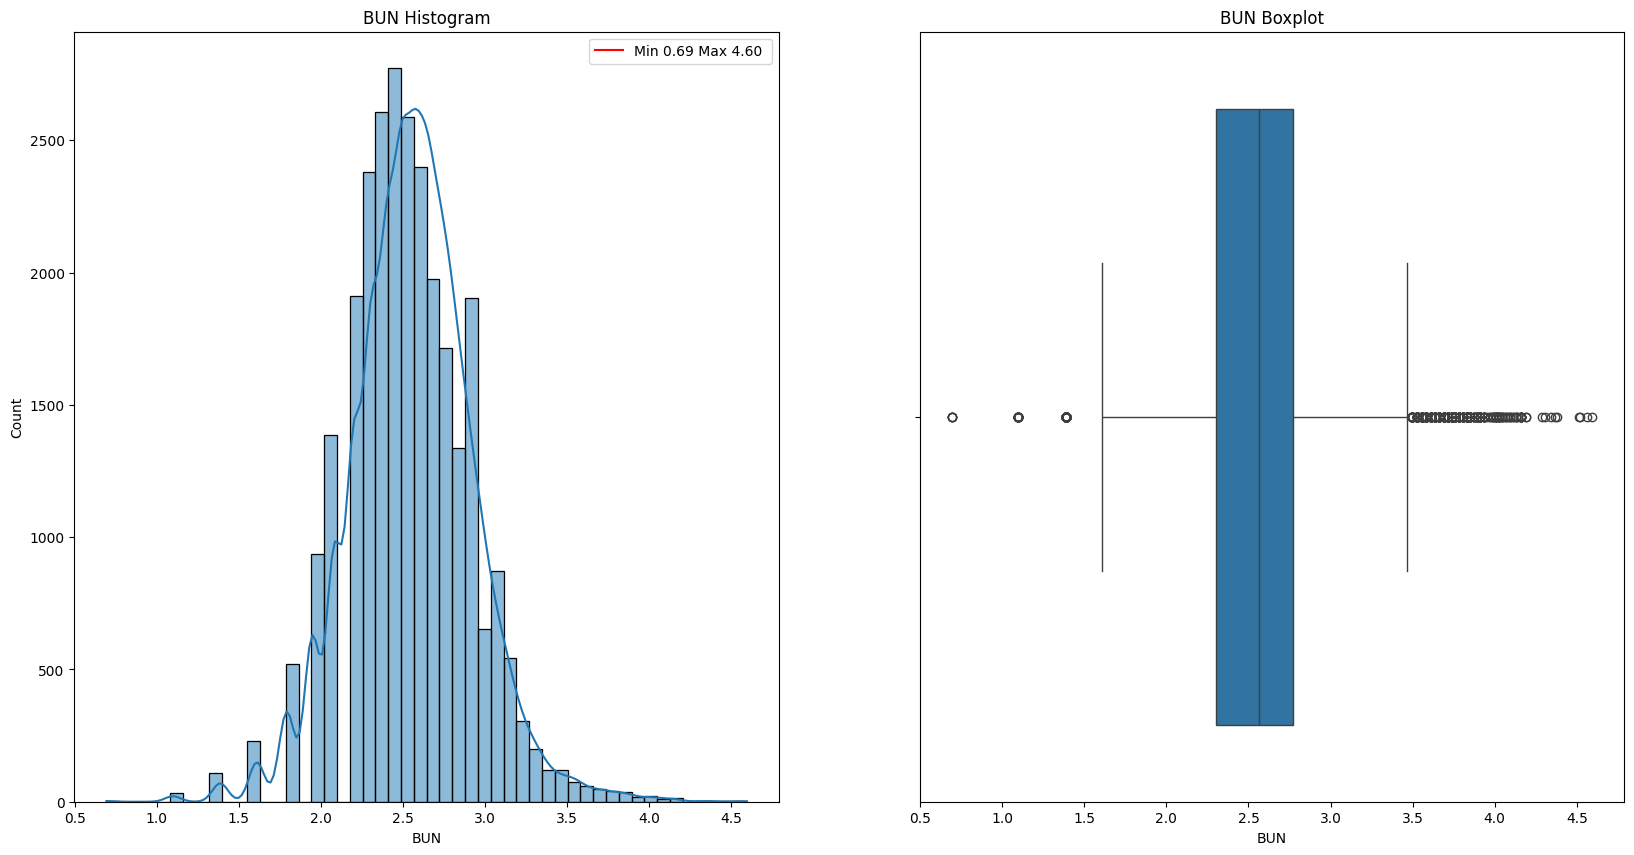

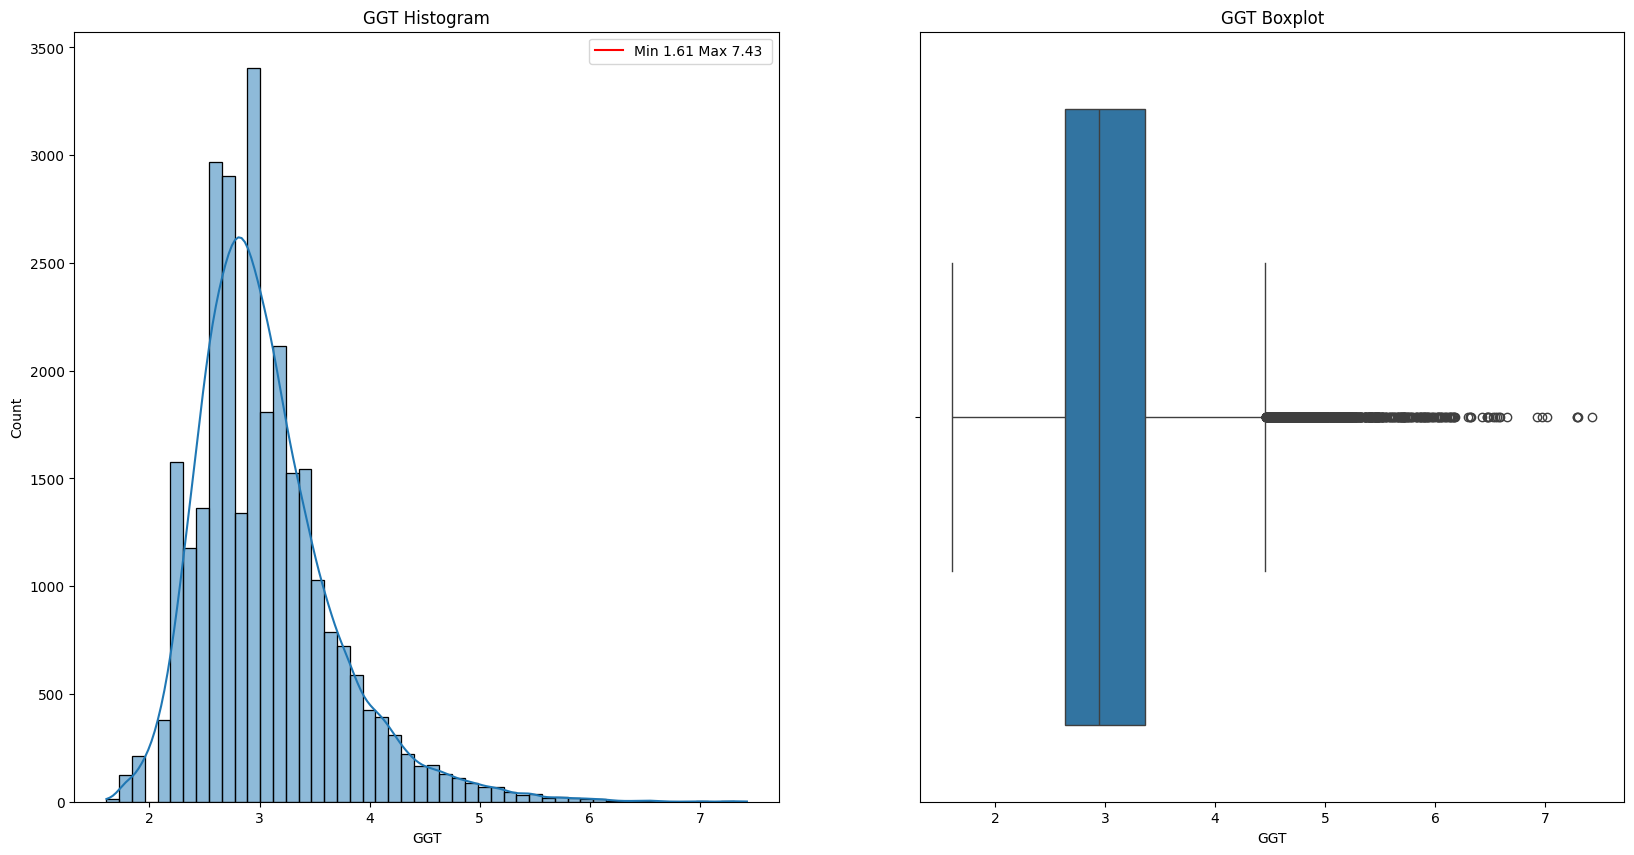

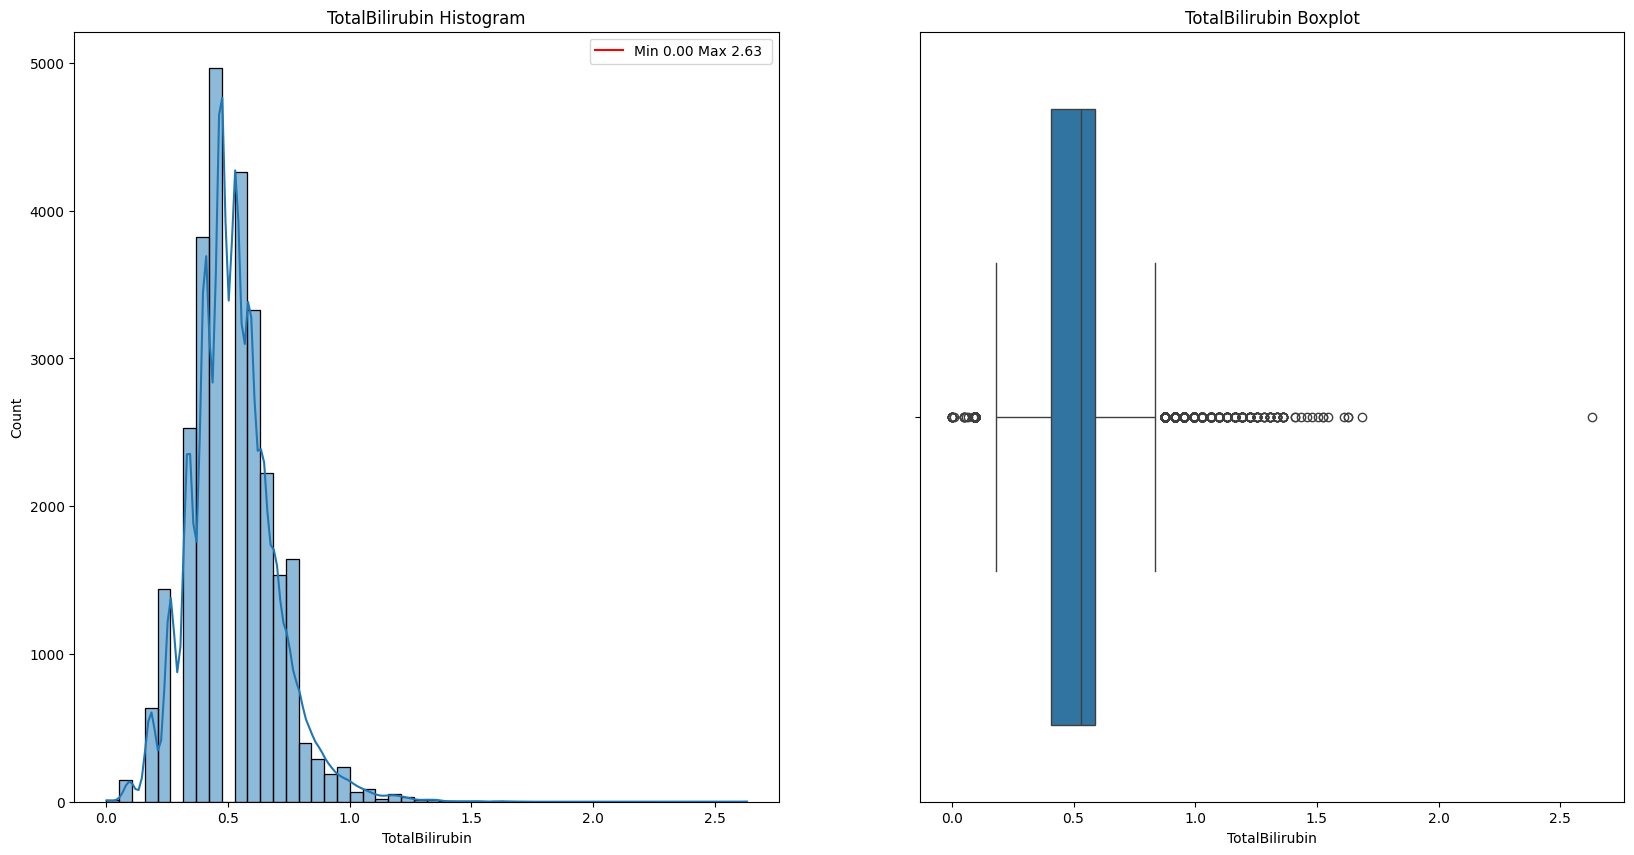

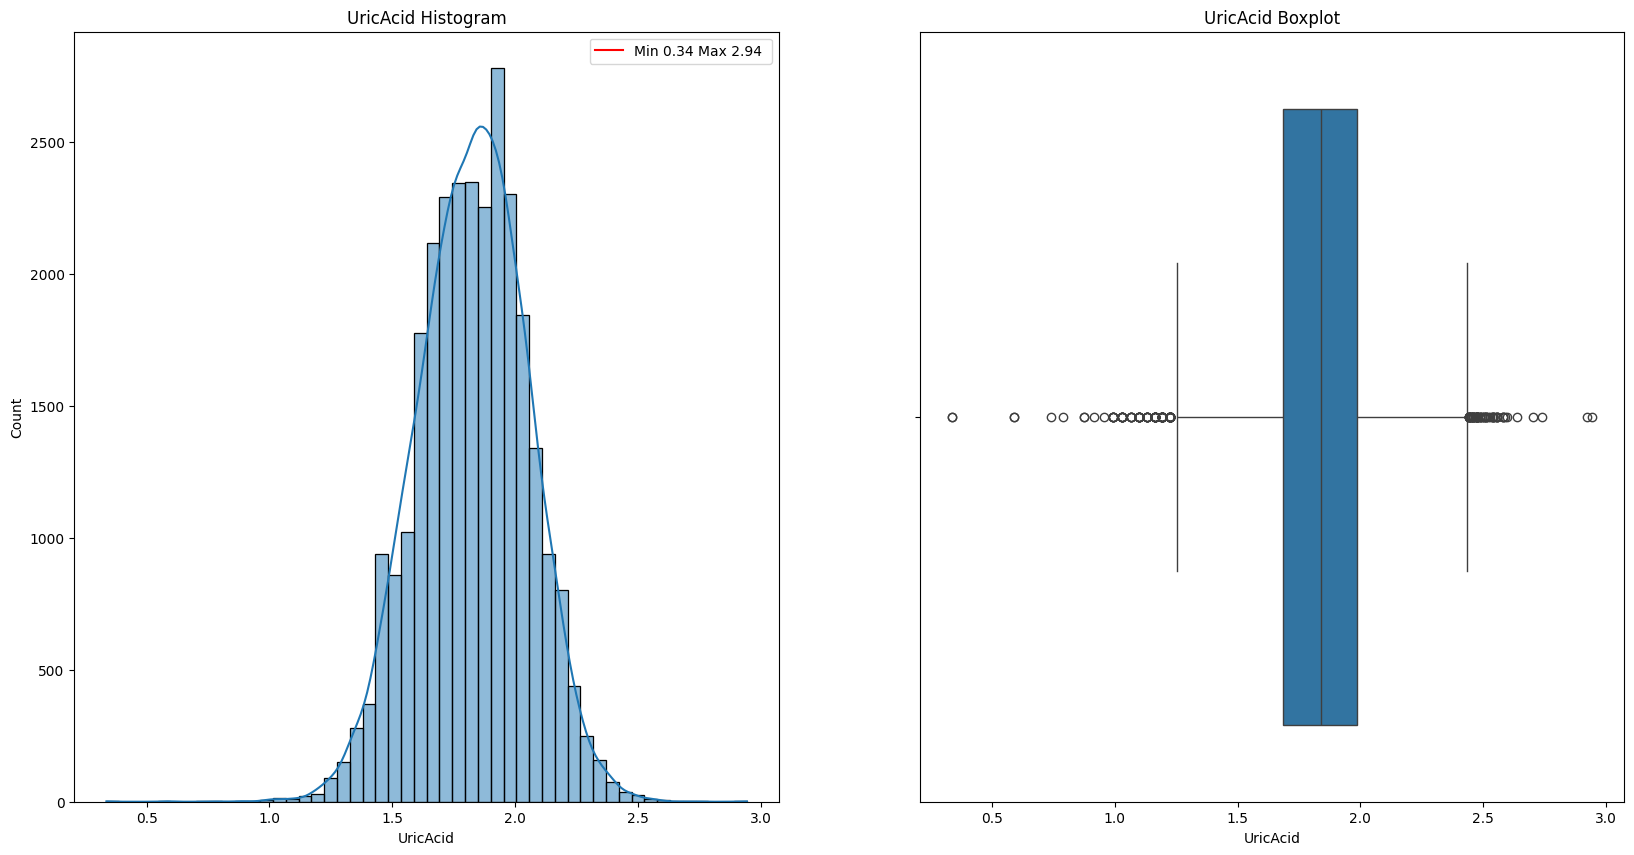

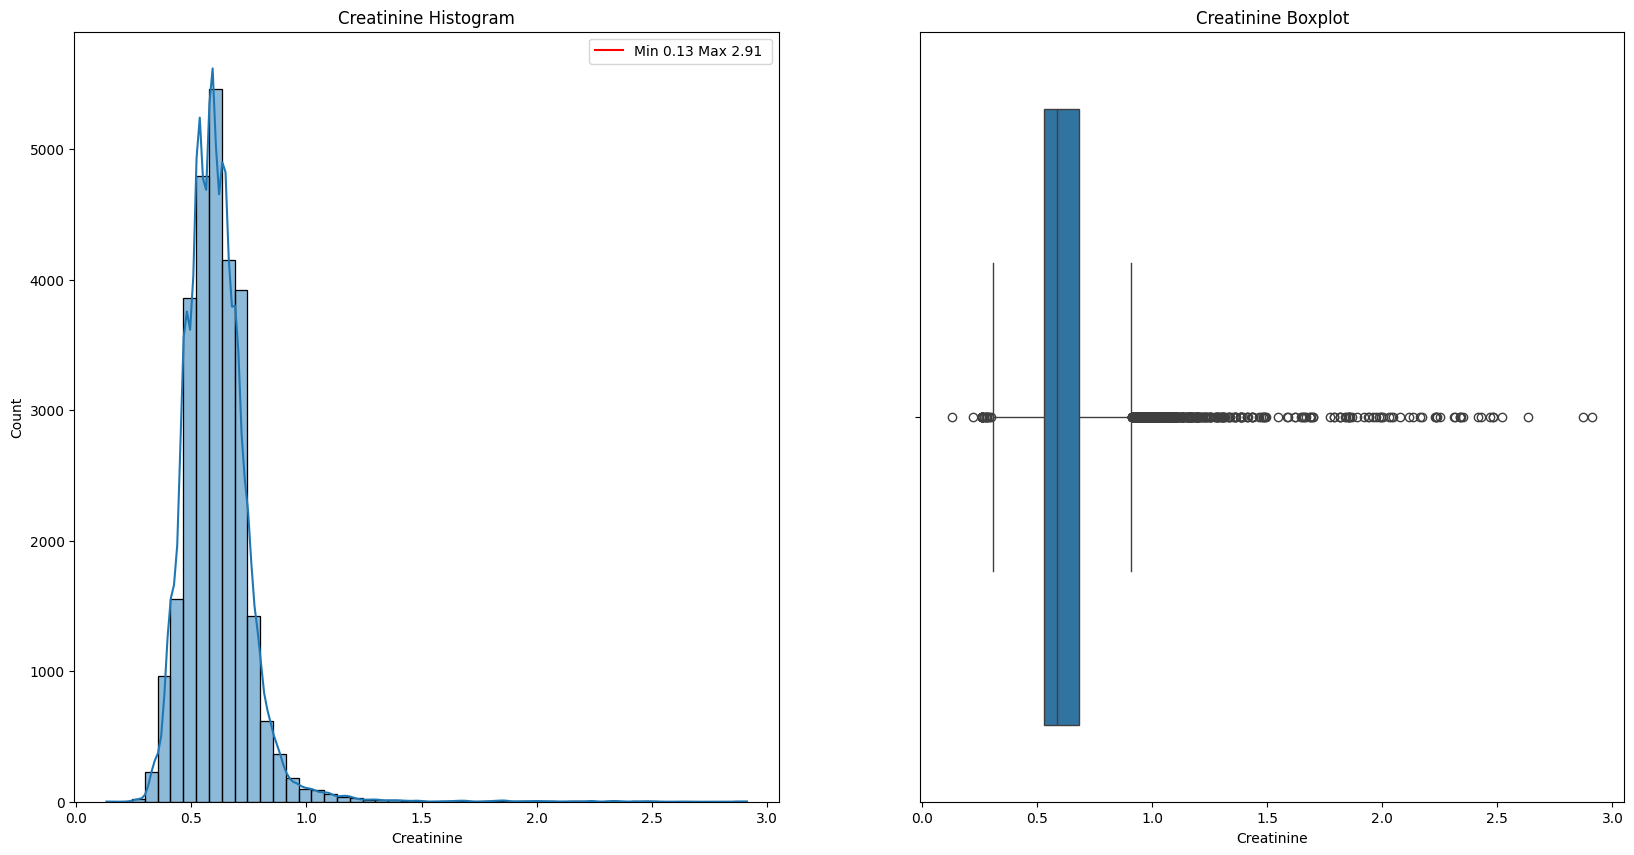

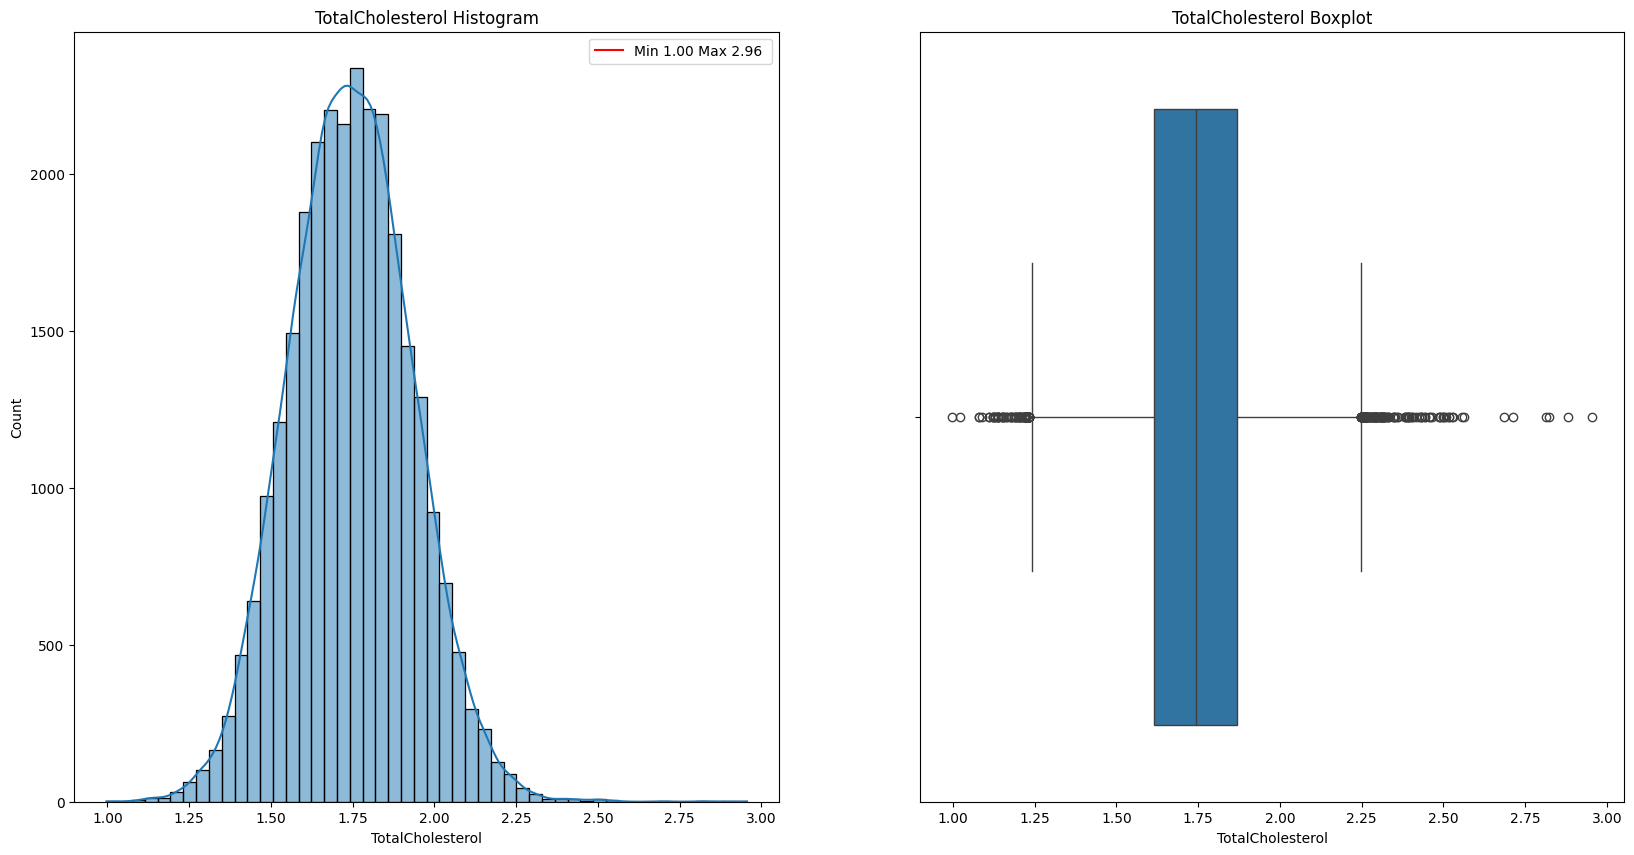

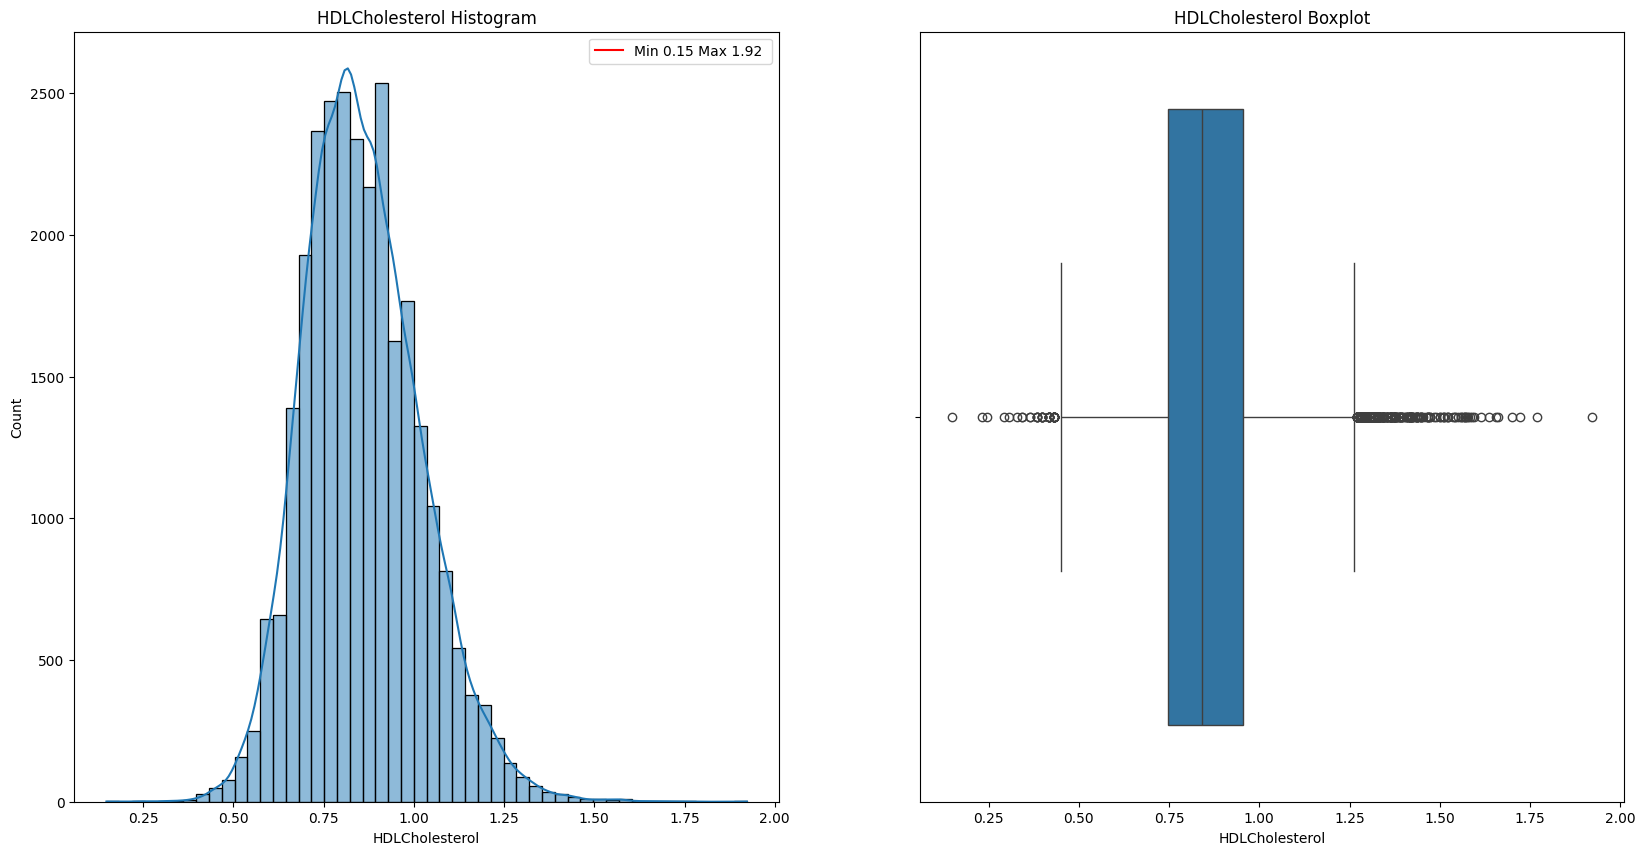

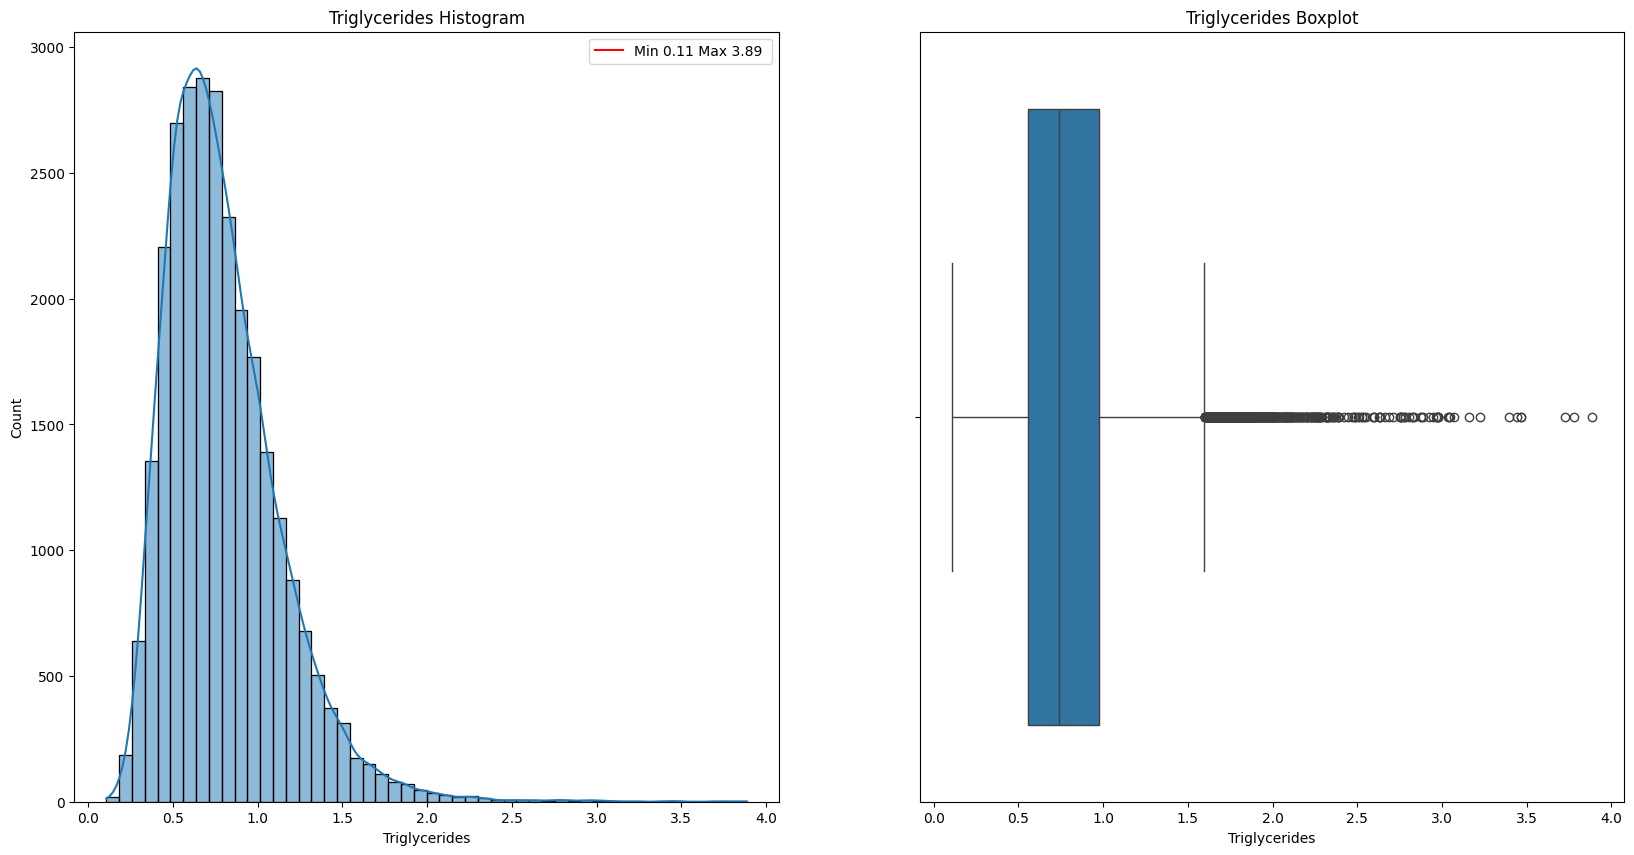

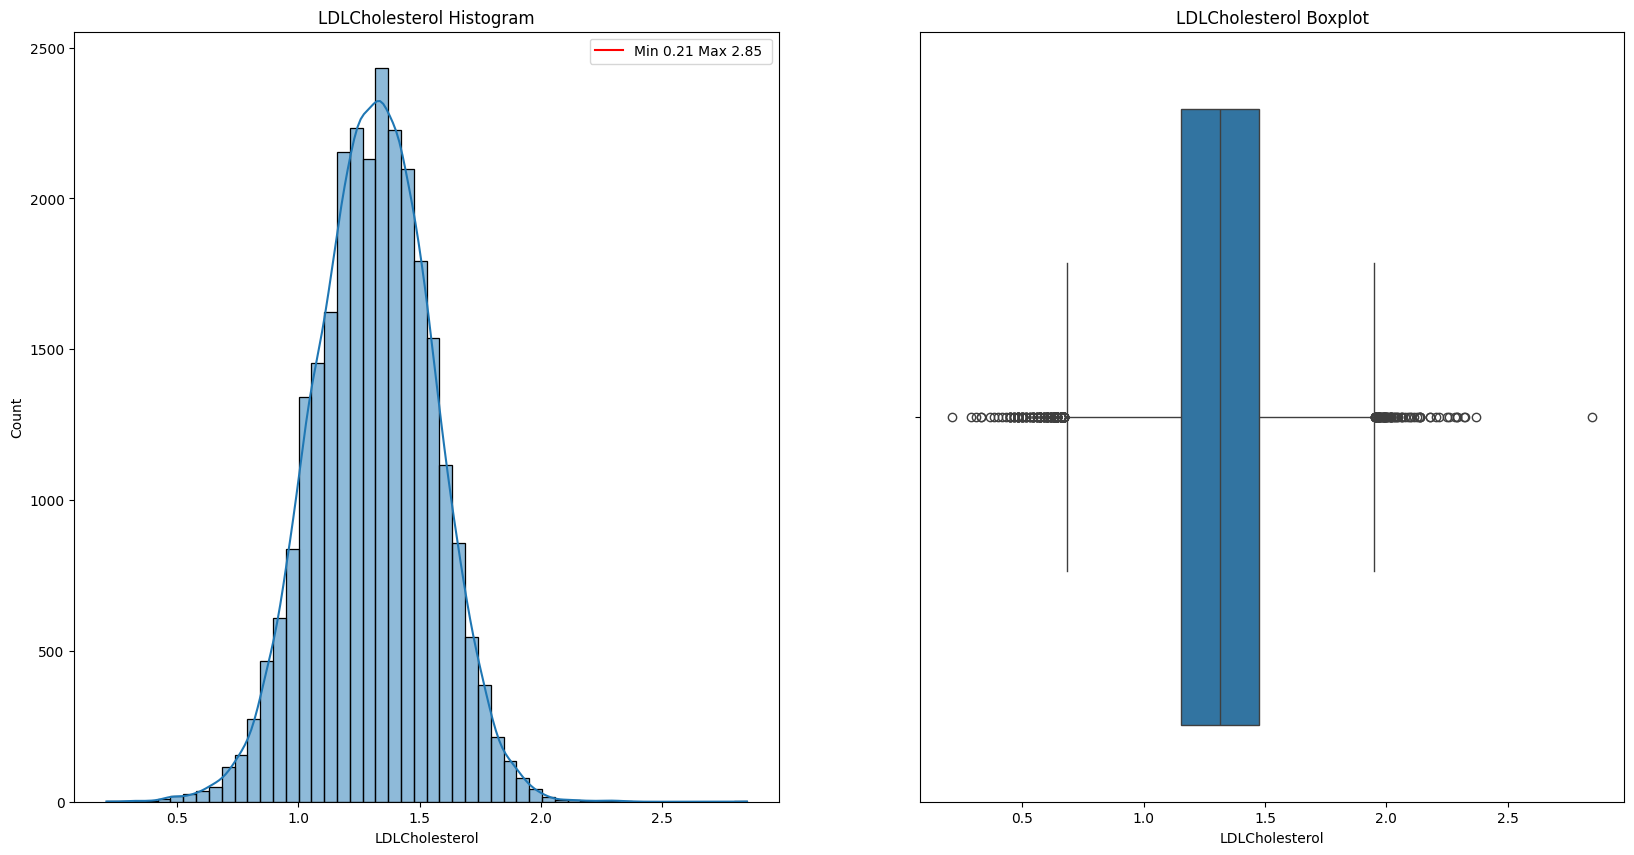

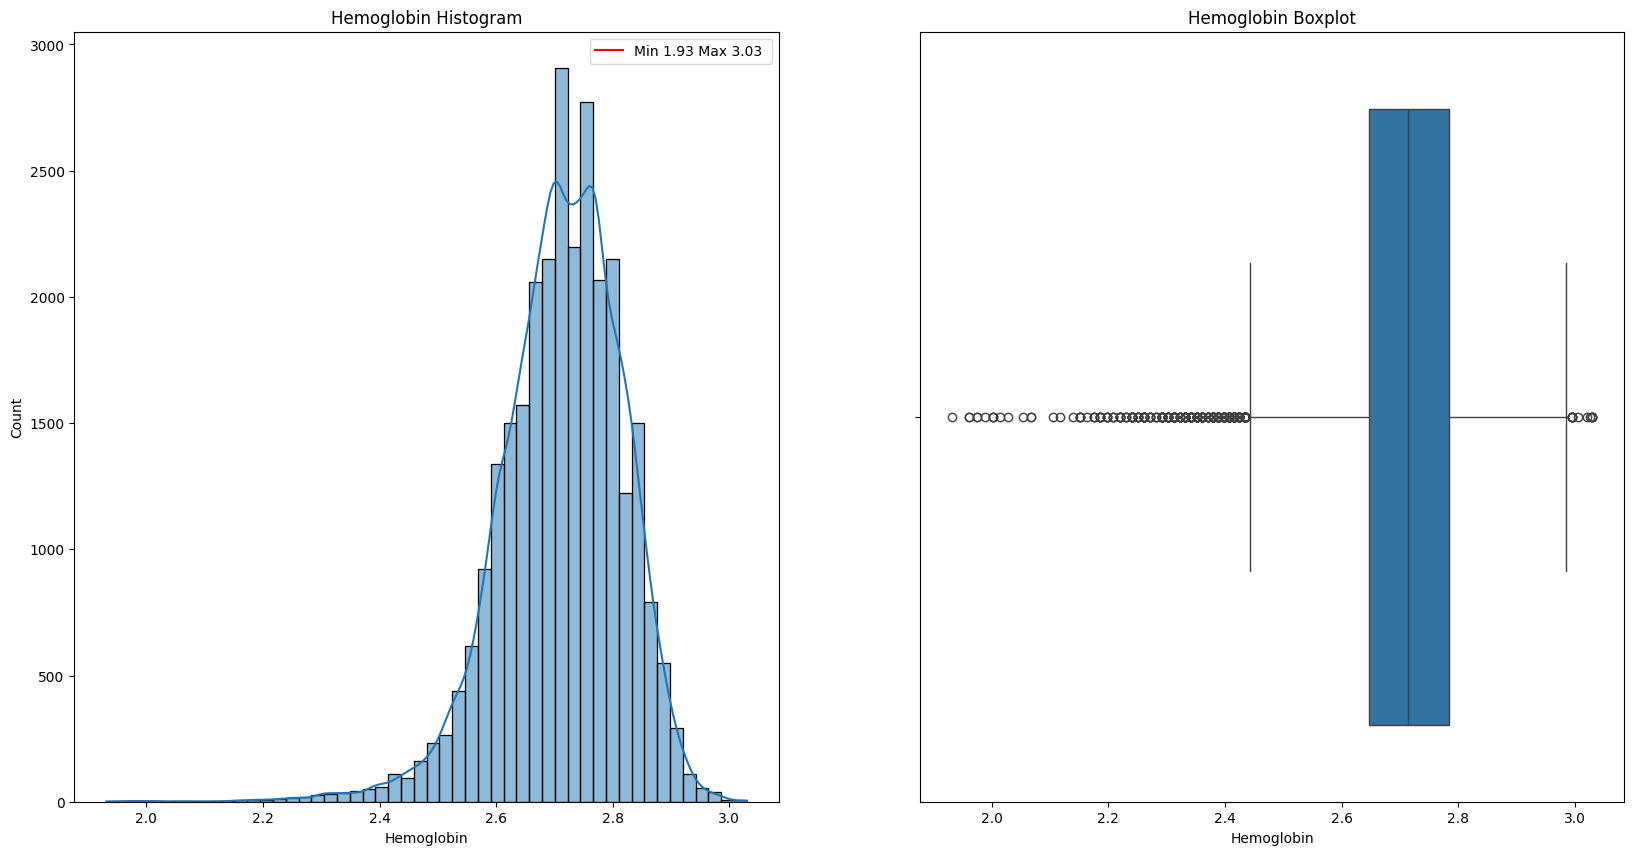

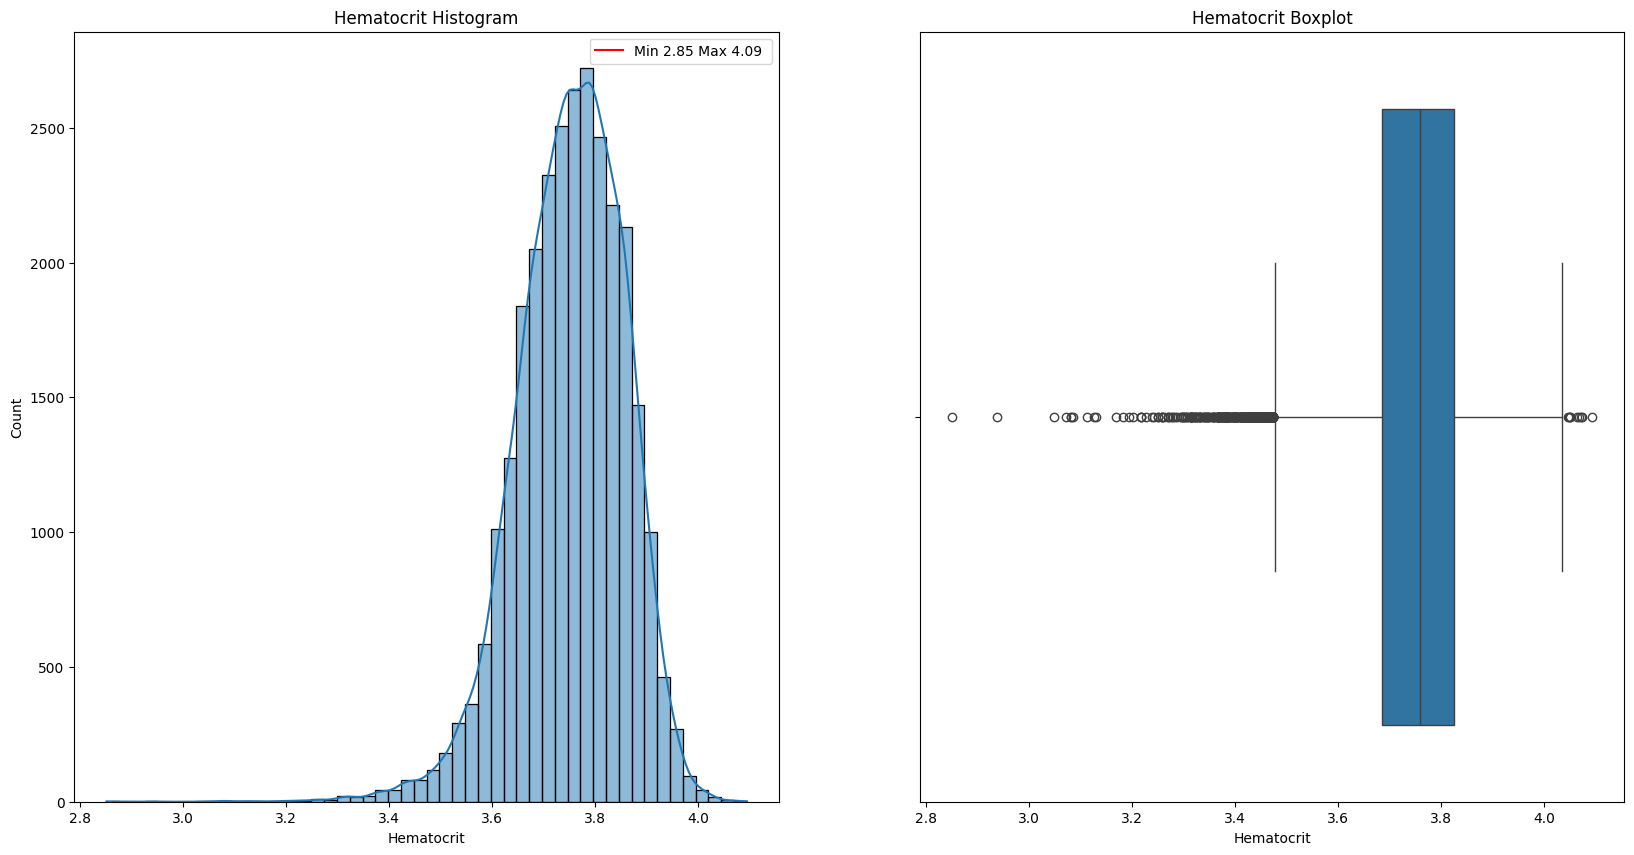

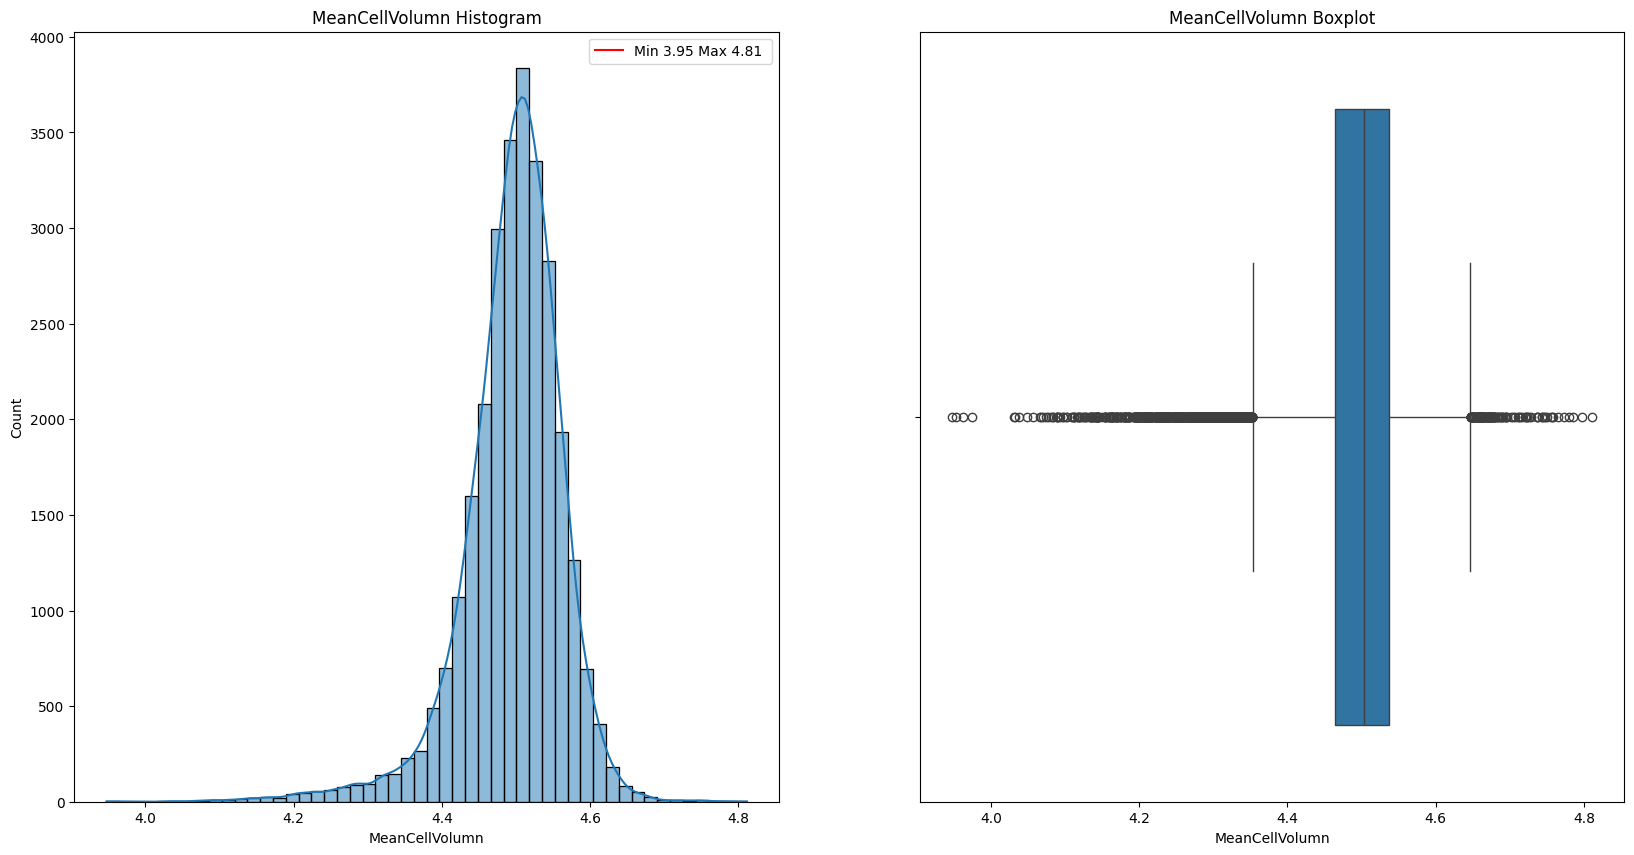

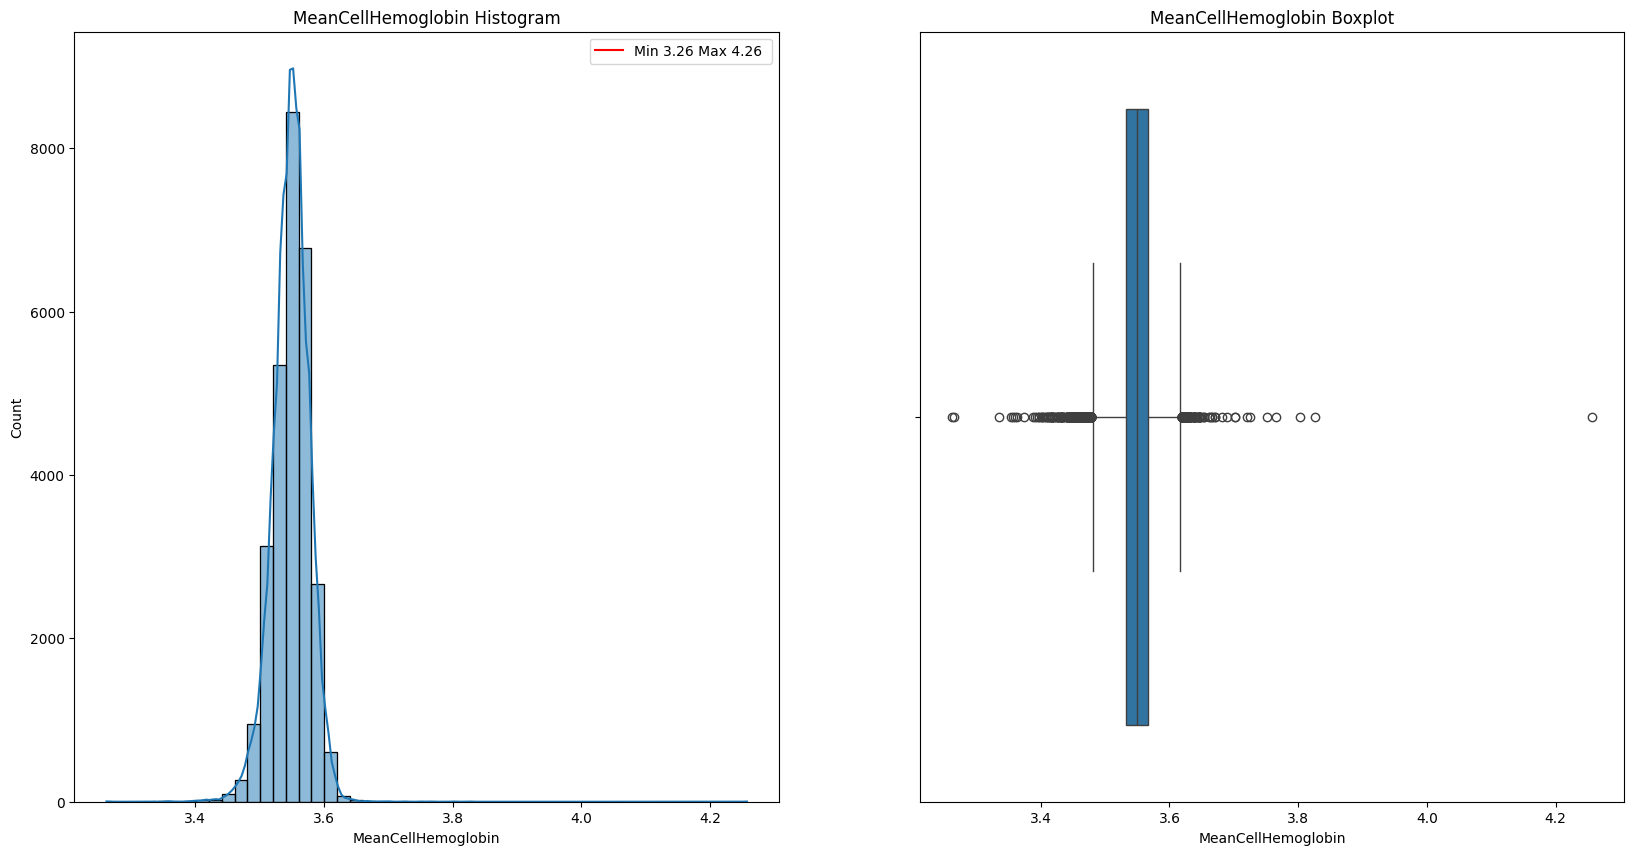

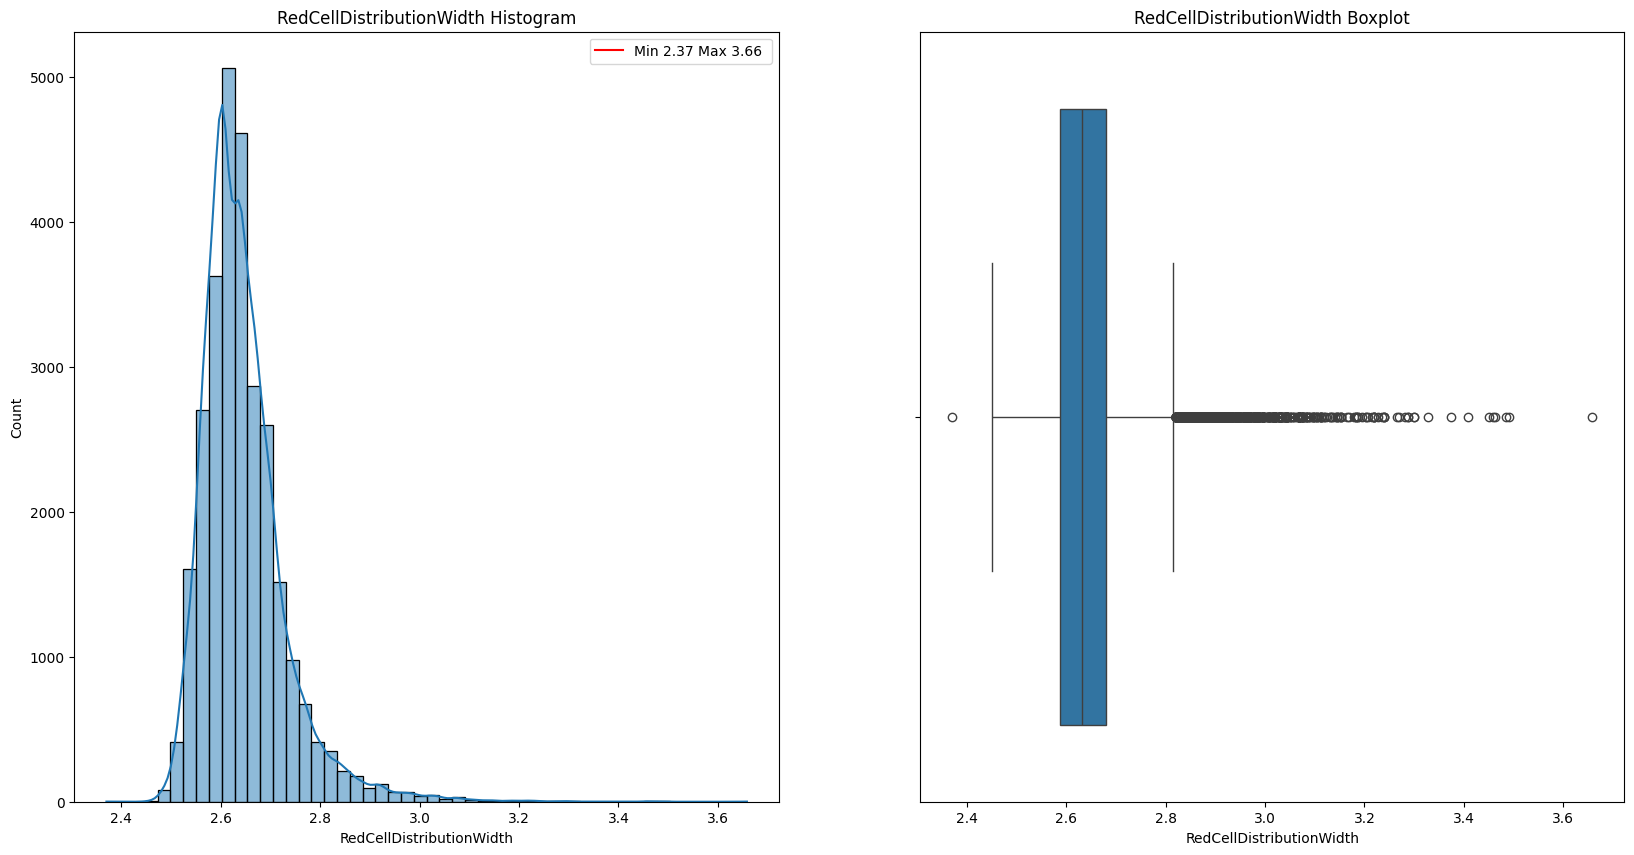

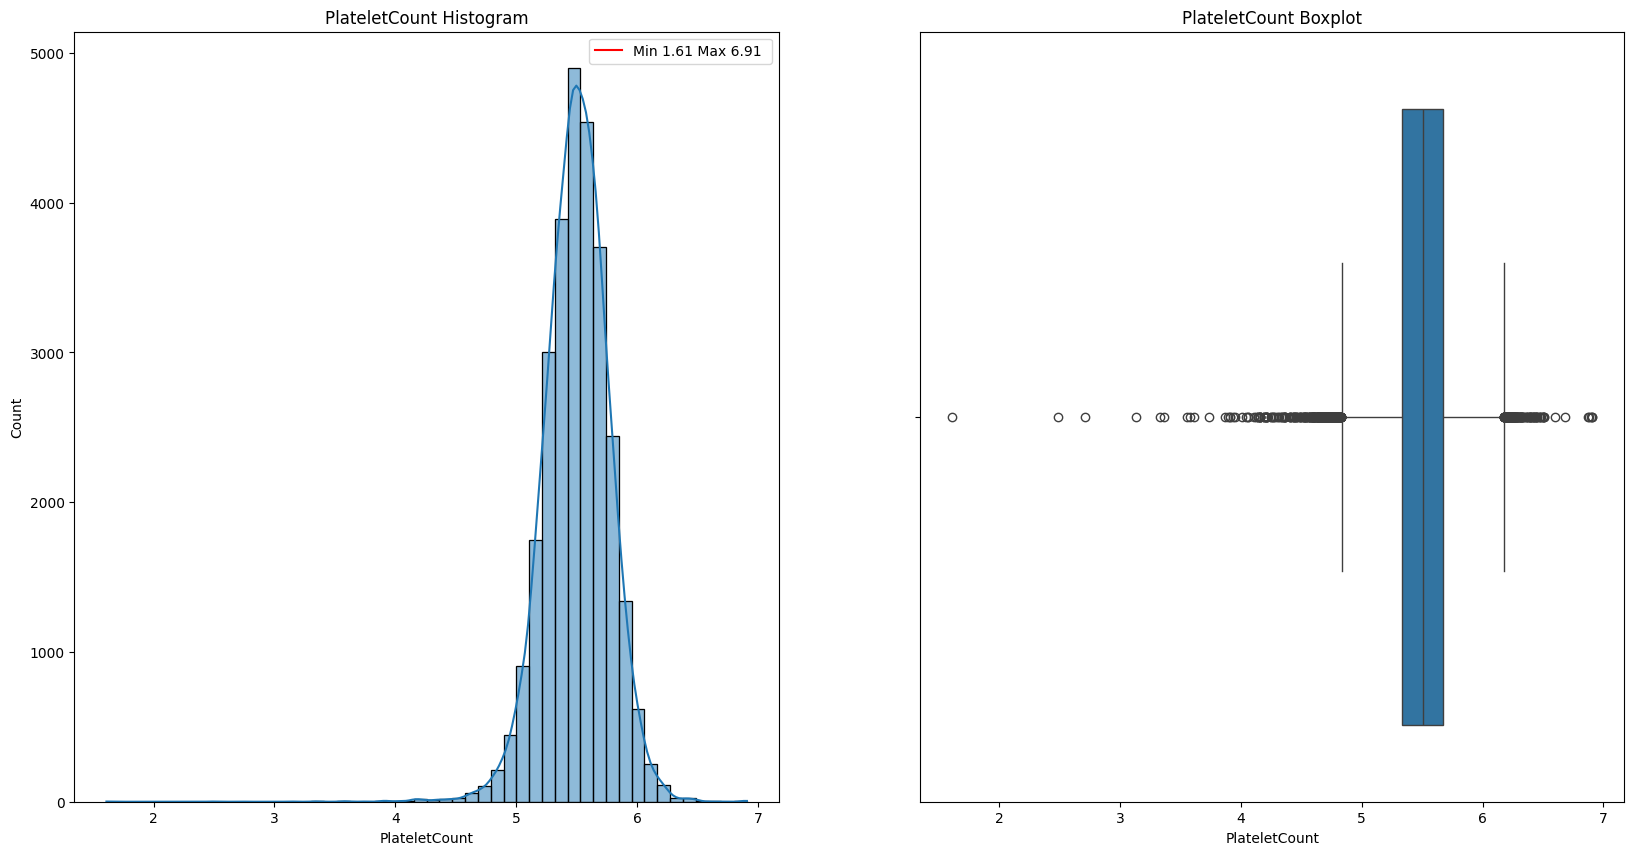

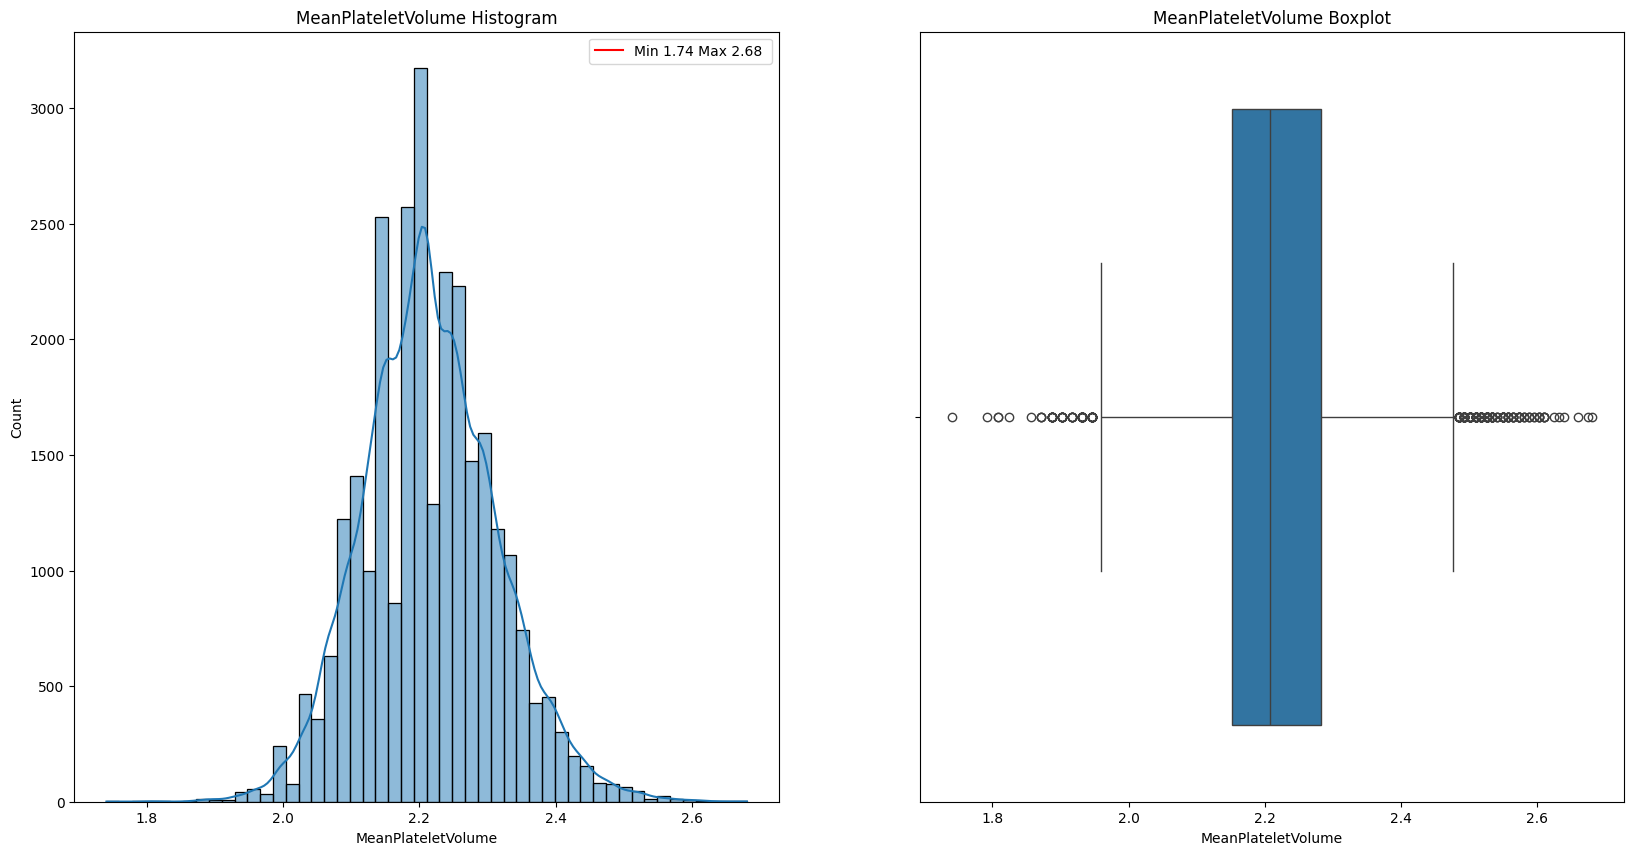

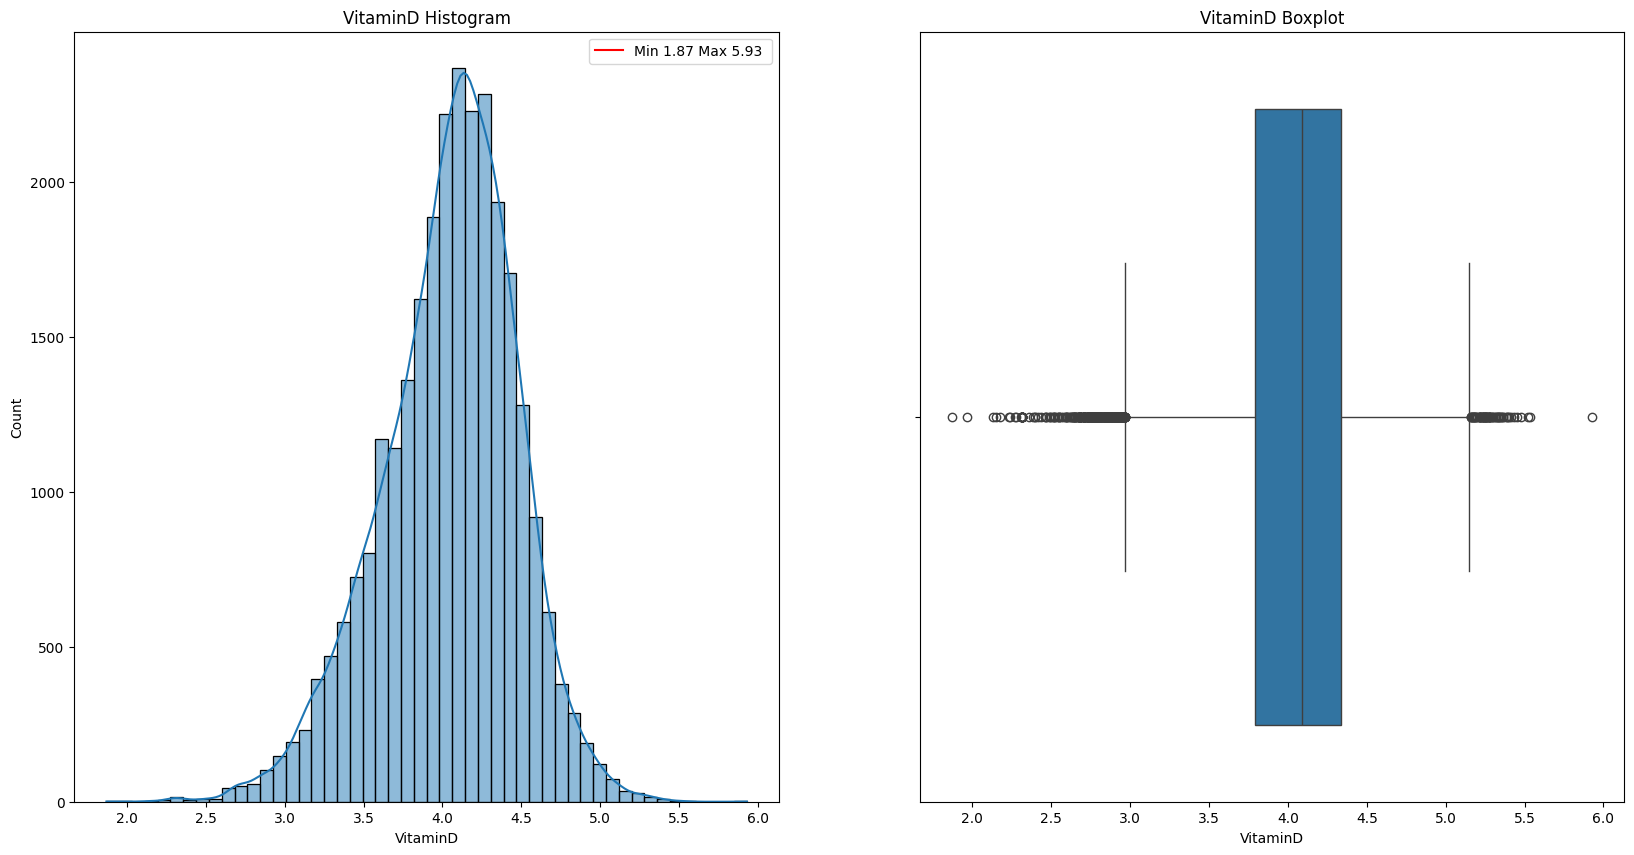

In [5]:
df_scaled = df_dq.copy()
df_scaled.drop(columns=['Gender', 'Race', 'milk_consumption'], inplace=True)
df_scaled = df_scaled.apply(lambda x: np.log1p(x))

for col in df_scaled.columns:
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    sns.histplot(df_scaled[col], bins=50, kde=True)
    plt.plot([], [], label = f"Min {df_scaled[col].min():.2f} Max {df_scaled[col].max():.2f} ", color='red')
    plt.legend()
    plt.title(f"{col} Histogram")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_scaled[col])
    plt.title(f"{col} Boxplot")

    plt.show()

### Data quality

#### Utils function

In [6]:
def draw_percent(values, columns):
    plt.figure(figsize=(20, len(columns) * 0.4))  # Dynamically adjust height
    plt.title("Completeness Ratio")
    ax = sns.barplot(x=values, y=columns, palette='viridis')

    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_width(),  # Move text slightly right of bar
            rec.get_y() + rec.get_height() / 2,
            f'{values[i]:.2%}',
            va='center'
        )

    plt.tight_layout()
    plt.show()

#### 1. Completeness

##### 1.1 Measure for each features

In [7]:
# Loop through each column and check for percent missing values for each column
def check_missing_ratio(df_check):
    ratio_completeness = []
    for column in df_check.columns:
        completeness_ratio = df_check[column].notnull().sum() / len(df_check)
        ratio_completeness.append(completeness_ratio)

    draw_percent(ratio_completeness, df_check.columns)


C:\Users\duyp6\AppData\Local\Temp\ipykernel_13828\3609807095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=columns, palette='viridis')


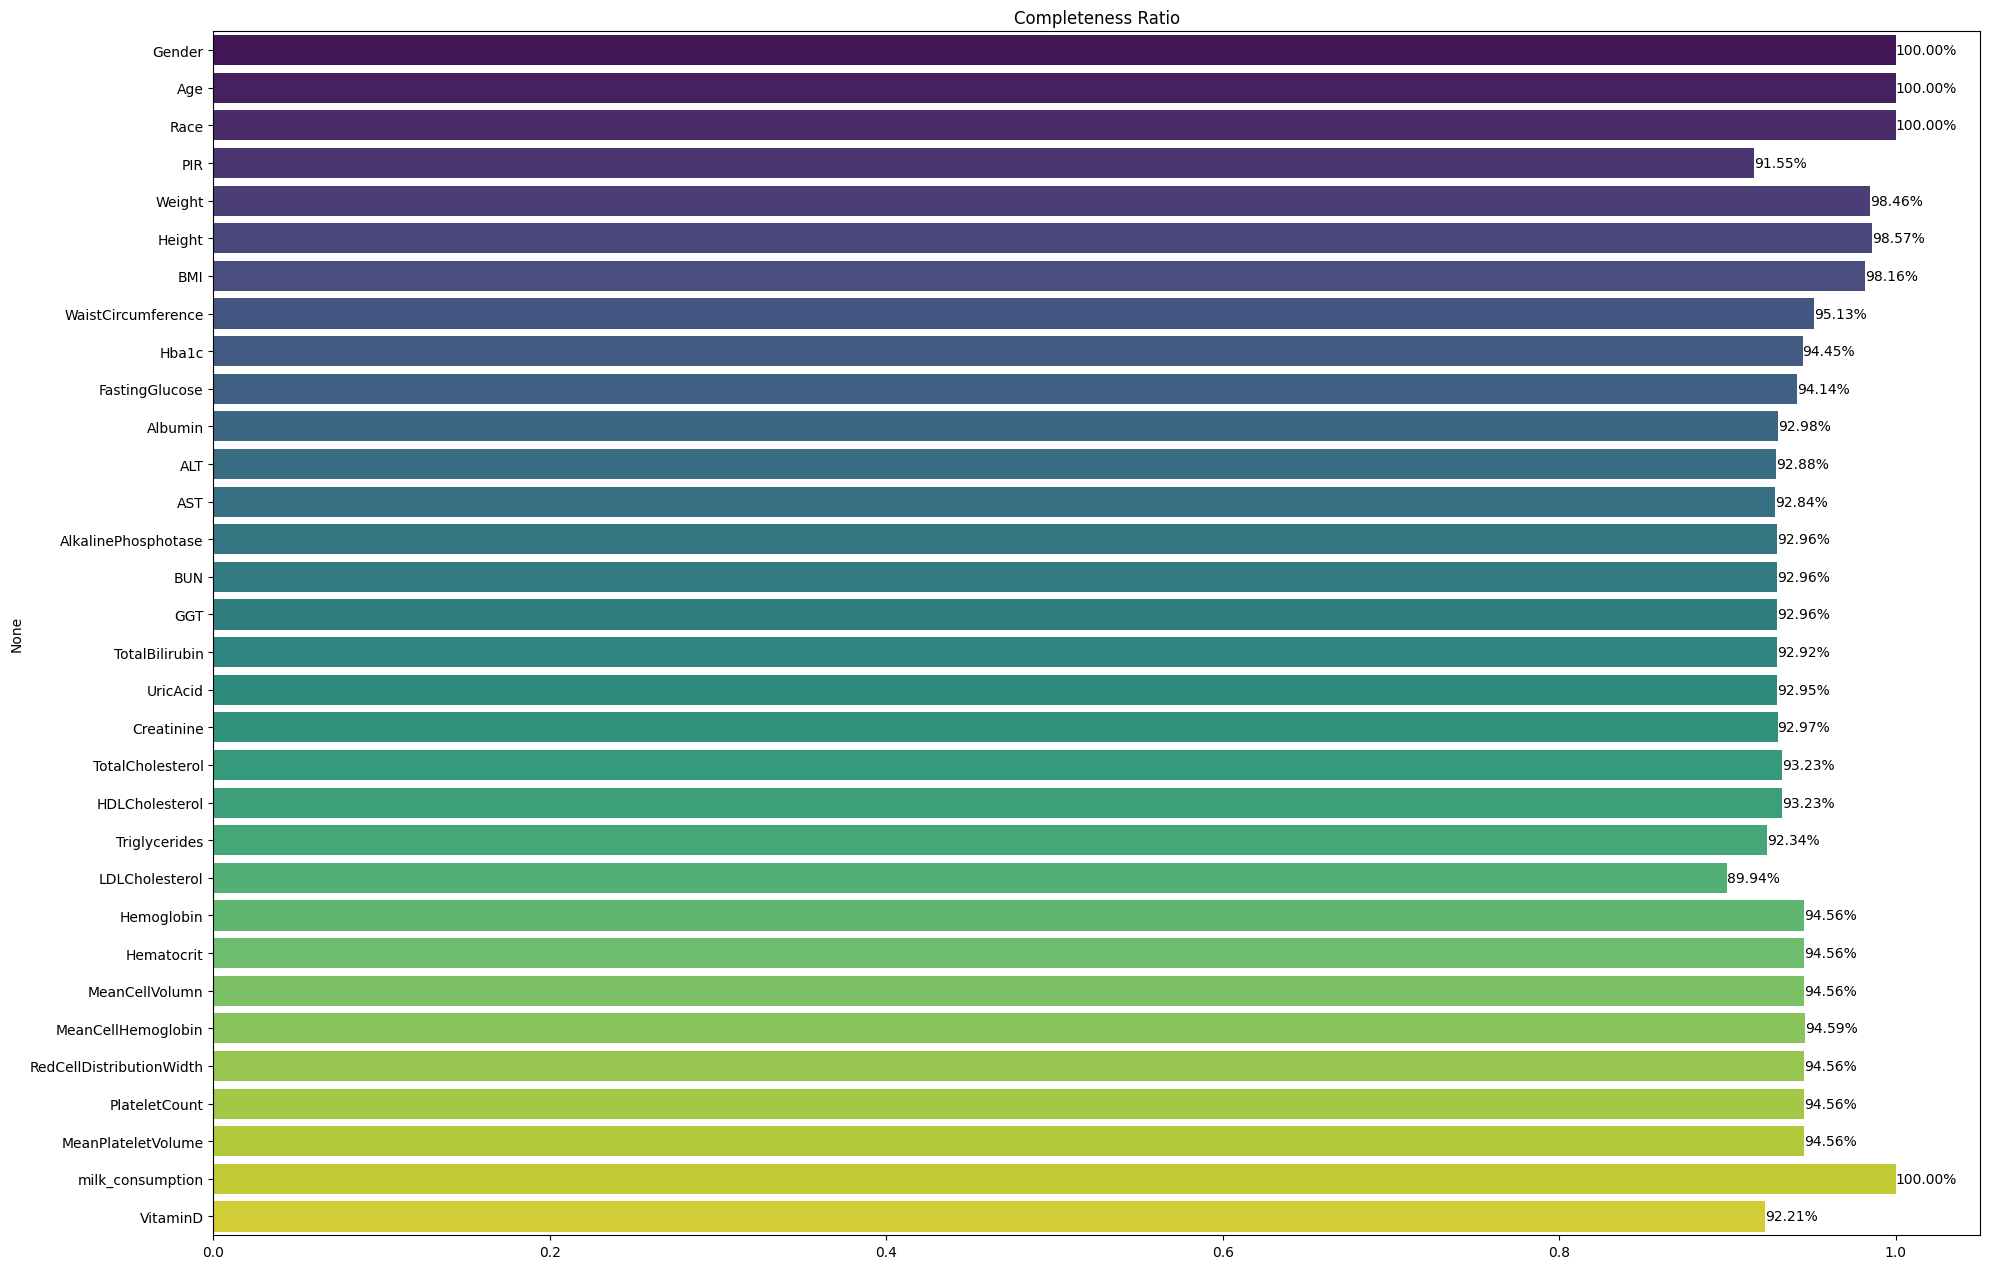

In [8]:
check_missing_ratio(df_dq)

##### 1.2 Measure for each record (row) and all dataset

In [9]:
missing_ratio_list = []

# Loop through each record (row) and cal missing ratio
for index, row in df_dq.iterrows():
    missing_ratio_row = row.isnull().sum() / len(row)
    missing_ratio_list.append(missing_ratio_row)

# Cal average missing ratio for all dataset
ratio_dataset = np.mean(missing_ratio_list)
print(f"Average missing ratio for dataset: {ratio_dataset:.2%}")

Average missing ratio for dataset: 5.32%


#### 2. Accuracy - Acc-DQ (new formula)

In [ ]:
# Need trusted resource so we can not measure this dimension

#### 3. Consistency

### Data Consistency Evaluation Factors

1. Value Ranges
   - Verified: All values remain within reasonable and expected ranges.

2. Non-null Data
   - Verified: Previously addressed during the data completeness assessment.

3. Data Types
   - Verified: No data type inconsistencies or errors detected.

4. Logical Constraints (In Progress)
   - Status: Validating that relationships between data columns are logically sound.

5. Uniqueness
   - Verified: No unexpected duplicate values identified in the dataset.

6. Referential Integrity
   - Status: The SEQN column is utilized as the primary foreign key identifier across all data tables.

##### 3.1 Check range value

In [10]:
# Check wrong data that has value out of range - Laboratory measures
# Take Note: 100000 presentation +oo because document does not specify the upper limit
measure_range_laboratory = {
    "Hba1c":{
        "min": 3.1,
        "max": 19.5
    },
    "FastingGlucose": {
        "min": 2,
        "max": 728,
    },
    "Albumin": {
        "min": 0.3,
        "max": 50,
    },
    "ALT": {
        "min": 3,
        "max": 7000,
    },
    "AST": {
        "min": 3,
        "max": 7000,
    },
    "AlkalinePhosphotase": {
        "min": 2,
        "max": 6000,
    },
    "BUN": {
        "min": 2,
        "max": 336,
    },
    "GGT": {
        "min": 3,
        "max": 13200,
    },
    "TotalBilirubin": {
        "min": 0.1,
        "max": 175.5,
    },
    "UricAcid": {
        "min": 0.2,
        "max": 62.5,
    },
    "Creatinine": {
        "min": 0.10,
        "max": 122.04,
    },
    "TotalCholesterol": {
        "min": 0.3,
        "max": 258.06,
    },
    "HDLCholesterol": {
        "min": 0.103,
        "max": 5.8,
    },
    "Triglycerides": {
        "min": 0,
        "max": 100000,
    },
    "LDLCholesterol": {
        "min": 0,
        "max": 100000,
    },
    "Hemoglobin": {
        "min": 0,
        "max": 25,
    },
    "Hematocrit": {
        "min": 0,
        "max": 100000,
    },
    "MeanCellVolumn": {
        "min": 50,
        "max": 150,
    },
    "MeanCellHemoglobin": {
        "min": 0,
        "max": 100000,
    },
    "RedCellDistributionWidth": {
        "min": 0,
        "max": 100000,
    },
    "PlateletCount": {
        "min": 0,
        "max": 999,
    },
    "MeanPlateletVolume": {
        "min": 5,
        "max": 20,
    }
}

In [ ]:
# Handle noise for Demographic and Examination and Questionnaire
# List of columns: Gender, Age, Race, PIR, milk_consumption
list_columns_remain = ['Gender', 'Age', 'Race', 'PIR', 'milk_consumption']

measure_range_remaining = {
    'Gender': {'min': 1, 'max': 2},
    'Age': {'min': 0, 'max': 200},
    'Race': {'min': 1, 'max': 5},
    'PIR': {'min': 0, 'max': 5},
    'milk_consumption': {'min': 0, 'max': 5}
}


In [12]:
# Check noise value for each column that is belong to continuous property
'''
   Strategy to check noise value:
    1. Use boxplot to visualize outliers
    2. Use Z-score to detect outliers
      2.1 If Top value range equal 100000 => only check Z-score > 3
      2.2 Else if value out of range min && max => Noise
    3. Measure Consistency ratio
'''
          
def check_noise_value(df_dq):
    df_check = df_dq.copy()
    list_noise_columns = []
    for col in df_check.columns:
        if col in measure_range_laboratory.keys():
            count = 0
            # Calculate Z-score of column
            z_score = (df_check[col] - df_check[col].mean()) / df_check[col].std()
            max_value = measure_range_laboratory[col].get("max")
            min_value = measure_range_laboratory[col].get("min")
            if max_value >= 100000:
                count = ((z_score.abs() > 3) & (pd.notna(df_check[col]))).sum()
            else:
                count = (((df_check[col] < min_value) | (df_check[col] > max_value)) & (pd.notna(df_check[col]))).sum()
            count = count / len(df_check)
            list_noise_columns.append((col, count))
    return list_noise_columns

C:\Users\duyp6\AppData\Local\Temp\ipykernel_13828\3609807095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=columns, palette='viridis')


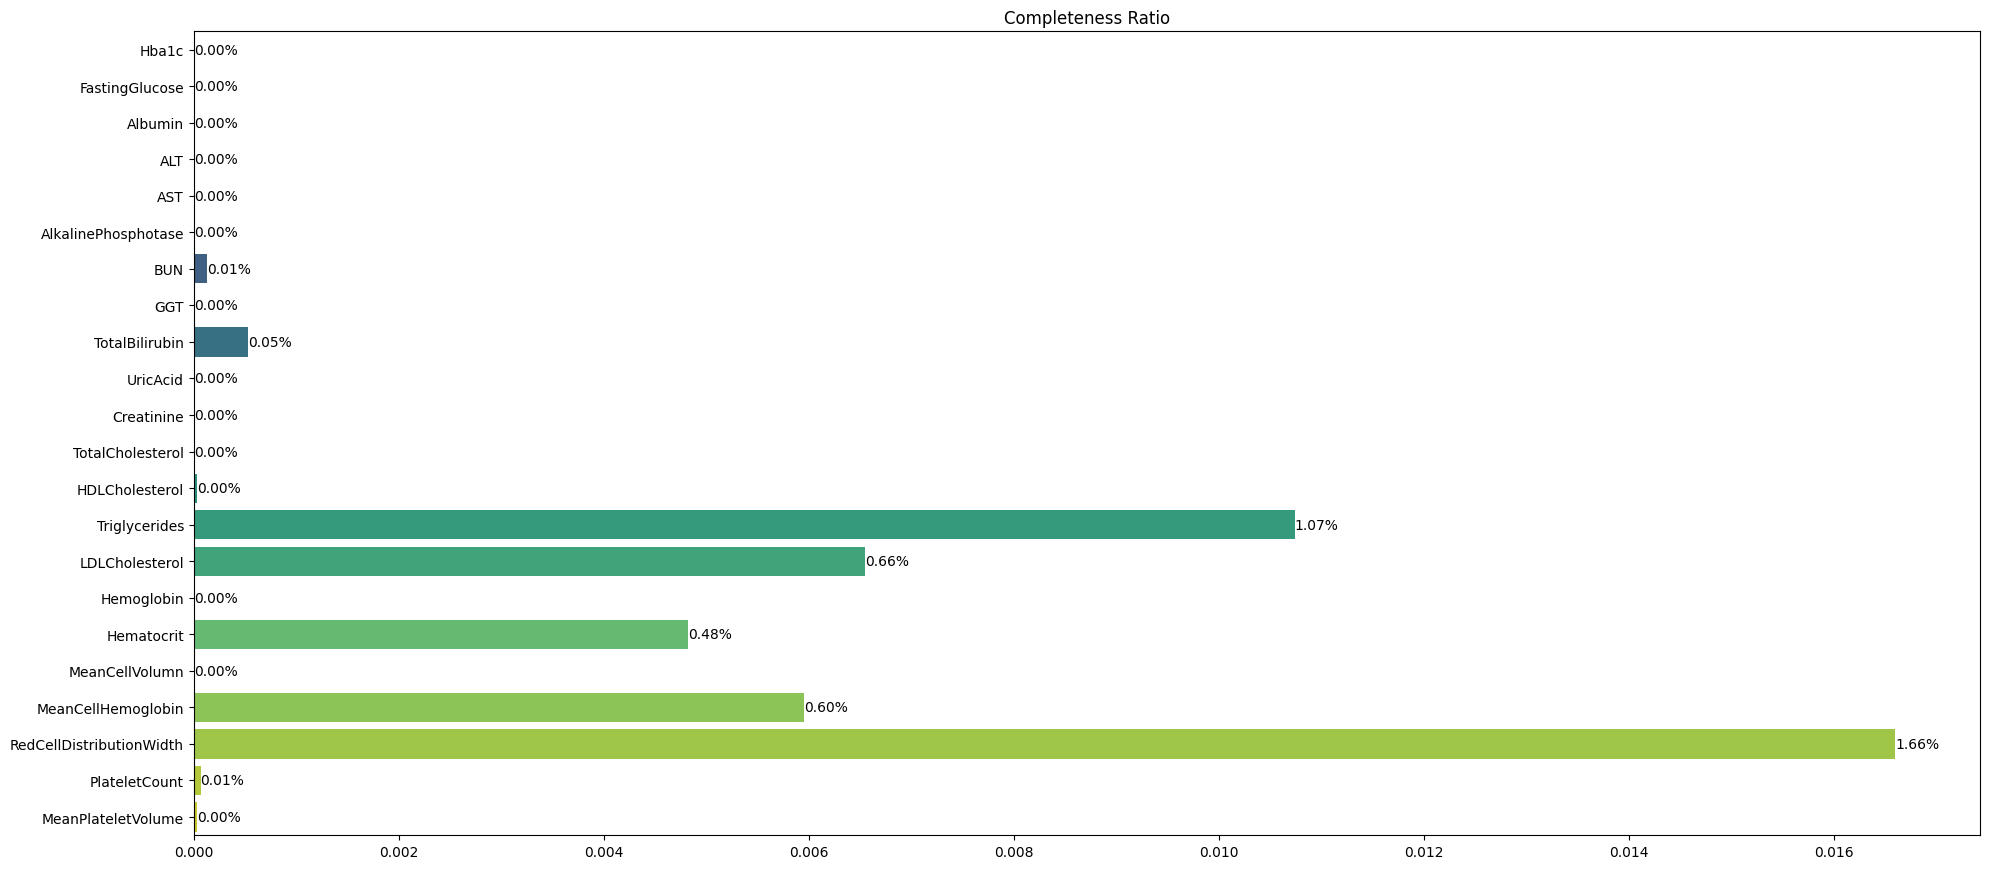

In [13]:
list_noise_continuous_columns = check_noise_value(df_dq)

draw_percent(
    [count for _, count in list_noise_continuous_columns],
    [col for col, _ in list_noise_continuous_columns]
)

In [14]:
# Check noise value for each column that is belong to category property
def check_noise_category_columns(df_dq):
    df_check = df_dq.copy()
    noise_category_columns = []
    for col in df_check.columns:
        if col in list_columns_remain:
          max_value = measure_range_remaining[col].get("max")
          min_value = measure_range_remaining[col].get("min")
          count = (((df_check[col] < min_value) | (df_check[col] > max_value)) & pd.notna(df_check[col])).sum()
          noise_category_columns.append((col, count/len(df_check)))

    return noise_category_columns

C:\Users\duyp6\AppData\Local\Temp\ipykernel_13828\3609807095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=columns, palette='viridis')


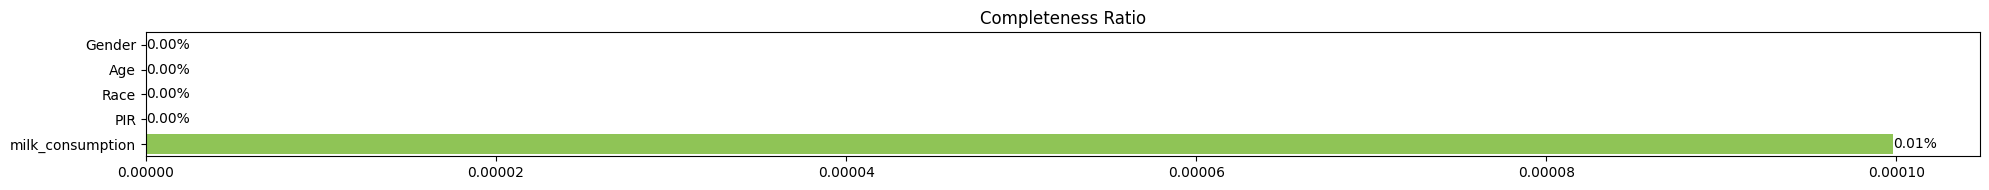

In [15]:
list_noise_category_columns = check_noise_category_columns(df_dq)
draw_percent(
    [count for _, count in list_noise_category_columns],
    [col for col, _ in list_noise_category_columns]
)

In [16]:
# Check noise value for each row
list_noise_value_row = [] 
for i, row in df_dq.iterrows():
    count = 0
    for col in df_dq.columns:
        if col in measure_range_laboratory.keys():
            max_value = measure_range_laboratory[col].get("max")
            min_value = measure_range_laboratory[col].get("min")
            if max_value >= 100000:
                z_score = (row[col] - df_dq[col].mean()) / df_dq[col].std()
                count += int((np.abs(z_score) > 3) & pd.notna(row[col]))
            else:
                count += int(((row[col] < min_value) | (row[col] > max_value)) & (pd.notna(row[col])))
        elif col in list_columns_remain:
            max_value = measure_range_remaining[col].get("max")
            min_value = measure_range_remaining[col].get("min")
            count += int(((row[col] < min_value) | (row[col] > max_value)) & pd.notna(row[col]))
    list_noise_value_row.append(count/len(df_dq.columns))
print(f"Average noise ratio for dataset: {np.mean(list_noise_value_row):.2%}")

Average noise ratio for dataset: 0.14%


##### 3.2 Check logical data

In [ ]:
# 4. Check data has type numeric but has negative values - check for each column first
for col in df_dq.columns:
    print(f"Columns: {col} has percentage of negative values: {df_dq[col][df_dq[col] < 0].count() / len(df_dq) * 100:.2f}%")


Columns: Gender has percentage of negative values: 0.00%
Columns: Age has percentage of negative values: 0.00%
Columns: Race has percentage of negative values: 0.00%
Columns: PIR has percentage of negative values: 0.00%
Columns: Weight has percentage of negative values: 0.00%
Columns: Height has percentage of negative values: 0.00%
Columns: BMI has percentage of negative values: 0.00%
Columns: WaistCircumference has percentage of negative values: 0.00%
Columns: Hba1c has percentage of negative values: 0.00%
Columns: FastingGlucose has percentage of negative values: 0.00%
Columns: Albumin has percentage of negative values: 0.00%
Columns: ALT has percentage of negative values: 0.00%
Columns: AST has percentage of negative values: 0.00%
Columns: AlkalinePhosphotase has percentage of negative values: 0.00%
Columns: BUN has percentage of negative values: 0.00%
Columns: GGT has percentage of negative values: 0.00%
Columns: TotalBilirubin has percentage of negative values: 0.00%
Columns: Uric

In [ ]:
# drop columns that are not needed to measure correlation
df_dq_numerics = df_dq.drop(columns=[
    "Gender", "Race"
    "milk_consumption"
])

# Check consistency between columns with spearman correlation
correlation_matrix = df_dq_numerics.corr(method = "spearman")

plt.figure(figsize=(20, 10))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

##### 3.3 Check duplicated value

In [20]:
# 5. Check row duplicated
df_dup = df[df.duplicated(subset= ["SEQN"], keep=False)]
print(f"Number of duplicated rows: {len(df_dup)}")
print("Percent of duplicated rows:", len(df_dup) / len(df) * 100, "%")

Number of duplicated rows: 0
Percent of duplicated rows: 0.0 %


#### 4. Timelineness

In [ ]:
# Data was updated continuously from 2001 to 2025